<a href="https://colab.research.google.com/github/riddhikad9b-ux/AeroGuard_Project/blob/main/Aero_guard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Cell 1: Environment Setup & Library Installation
print("Setting up Aéro Guard development environment...")

# 1. Install core geospatial and mapping dependencies
!pip install -q geopandas shapely folium osmnx requests pandas numpy

# 2. Mount Google Drive for saving session logs and mock data
from google.colab import drive
drive.mount('/content/drive')

# 3. Create project directory structure in Google Drive
import os
base_dir = '/content/drive/My Drive/AeroGuard_Project'
os.makedirs(f"{base_dir}/data", exist_ok=True)
os.makedirs(f"{base_dir}/models", exist_ok=True)
os.makedirs(f"{base_dir}/exports", exist_ok=True)

print(f"\nEnvironment ready! Workspace initialized at: {base_dir}")

Setting up Aéro Guard development environment...
Mounted at /content/drive

Environment ready! Workspace initialized at: /content/drive/My Drive/AeroGuard_Project


In [7]:

# Cell 2: OpenWeather API Integration & Environmental Data Fetcher
import requests
from getpass import getpass

# Prompt securely for your OpenWeather API key (or paste it when asked)
print("🔑 Please enter your OpenWeather API Key:")
OWM_API_KEY = getpass("API Key: ")

def get_environmental_data(city_name):
    """Fetches geocoding coordinates and live air pollution/weather data for any city."""
    # 1. Geocoding API to get latitude and longitude for the city
    geo_url = f"http://api.openweathermap.org/geo/1.0/direct?q={city_name}&limit=1&appid={OWM_API_KEY}"
    geo_resp = requests.get(geo_url).json()

    if not geo_resp:
        return f"Error: Location '{city_name}' not found."

    lat = geo_resp[0]['lat']
    lon = geo_resp[0]['lon']
    formatted_name = f"{geo_resp[0].get('name')}, {geo_resp[0].get('country')}"

    # 2. Current Air Pollution API (PM2.5, PM10, AQI)
    pollution_url = f"http://api.openweathermap.org/data/2.5/air_pollution?lat={lat}&lon={lon}&appid={OWM_API_KEY}"
    pollution_data = requests.get(pollution_url).json()

    # 3. Current Weather API (Temperature, Humidity)
    weather_url = f"https://api.openweathermap.org/data/2.5/weather?lat={lat}&lon={lon}&units=metric&appid={OWM_API_KEY}"
    weather_data = requests.get(weather_url).json()

    # Extract components safely
    components = pollution_data['list'][0]['components']
    aqi_level = pollution_data['list'][0]['main']['aqi'] # Scale 1 (Good) to 5 (Very Poor)

    result = {
        "Location": formatted_name,
        "Latitude": lat,
        "Longitude": lon,
        "AQI_Index": aqi_level,
        "PM2_5": components.get('pm2_5'),
        "PM10": components.get('pm10'),
        "Temperature_C": weather_data['main']['temp'],
        "Humidity_%": weather_data['main']['humidity']
    }
    return result

# Test the function with Porur, Chennai
test_city = "Porur, Chennai"
print(f"\n📡 Fetching live environmental metrics for {test_city}...")
live_metrics = get_environmental_data(test_city)

for key, val in live_metrics.items():
    print(f"  • {key}: {val}")

🔑 Please enter your OpenWeather API Key:
API Key: ··········

📡 Fetching live environmental metrics for Porur, Chennai...


KeyError: 0

In [8]:
# Cell 2 (Fixed & Robust): OpenWeather API Integration
import requests
from getpass import getpass

# Prompt securely for your OpenWeather API key
print("🔑 Please paste your OpenWeather API Key below:")
OWM_API_KEY = getpass("API Key: ")

def get_environmental_data(city_query):
    """Fetches geocoding coordinates and live metrics with safe error handling."""
    # Use a clean city query (e.g. "Chennai,IN")
    geo_url = f"http://api.openweathermap.org/geo/1.0/direct?q={city_query}&limit=1&appid={OWM_API_KEY}"
    geo_resp = requests.get(geo_url).json()

    # Check if the API returned a valid list of locations
    if not isinstance(geo_resp, list) or len(geo_resp) == 0:
        print(f"\n[API Notice]: Received empty response for '{city_query}'.")
        print("Note: If you just created your OpenWeather key today, it can take up to 2 hours to activate on their servers.")
        print("Raw API Response:", geo_resp)
        return None

    lat = geo_resp[0]['lat']
    lon = geo_resp[0]['lon']
    formatted_name = f"{geo_resp[0].get('name')}, {geo_resp[0].get('country')}"

    # 2. Current Air Pollution API
    pollution_url = f"http://api.openweathermap.org/data/2.5/air_pollution?lat={lat}&lon={lon}&appid={OWM_API_KEY}"
    pollution_data = requests.get(pollution_url).json()

    # 3. Current Weather API
    weather_url = f"https://api.openweathermap.org/data/2.5/weather?lat={lat}&lon={lon}&units=metric&appid={OWM_API_KEY}"
    weather_data = requests.get(weather_url).json()

    components = pollution_data['list'][0]['components']
    aqi_level = pollution_data['list'][0]['main']['aqi']

    return {
        "Location": formatted_name,
        "Latitude": lat,
        "Longitude": lon,
        "AQI_Index": aqi_level,
        "PM2_5": components.get('pm2_5'),
        "PM10": components.get('pm10'),
        "Temperature_C": weather_data['main']['temp'],
        "Humidity_%": weather_data['main']['humidity']
    }

# Test with a broader query ("Chennai,IN") which is globally recognized by OpenWeather
test_city = "Chennai,IN"
print(f"\n📡 Fetching live environmental metrics for {test_city}...")
live_metrics = get_environmental_data(test_city)

if live_metrics:
    for key, val in live_metrics.items():
        print(f"  • {key}: {val}")

🔑 Please paste your OpenWeather API Key below:
API Key: ··········

📡 Fetching live environmental metrics for Chennai,IN...

[API Notice]: Received empty response for 'Chennai,IN'.
Note: If you just created your OpenWeather key today, it can take up to 2 hours to activate on their servers.
Raw API Response: {'cod': 401, 'message': 'Invalid API key. Please see https://openweathermap.org/faq#error401 for more info.'}


In [9]:
# Cell 2: Environmental Data Fetcher (with Fallback Mock Data for new keys)
import requests
from getpass import getpass

print("🔑 Please paste your OpenWeather API Key (or press Enter to use mock data for now):")
OWM_API_KEY = getpass("API Key: ")

def get_environmental_data(city_query):
    """Fetches live data, or falls back to realistic simulation data if the key is still activating."""
    if not OWM_API_KEY or len(OWM_API_KEY.strip()) < 10:
        print("\n[Notice]: Using simulated environmental data for testing (Key not provided).")
        return get_mock_data(city_query)

    geo_url = f"http://api.openweathermap.org/geo/1.0/direct?q={city_query}&limit=1&appid={OWM_API_KEY}"
    geo_resp = requests.get(geo_url).json()

    if not isinstance(geo_resp, list) or len(geo_resp) == 0:
        print(f"\n[API Notice]: Key is still activating (401/Empty). Switching to simulated data for now!")
        return get_mock_data(city_query)

    lat = geo_resp[0]['lat']
    lon = geo_resp[0]['lon']
    formatted_name = f"{geo_resp[0].get('name')}, {geo_resp[0].get('country')}"

    pollution_url = f"http://api.openweathermap.org/data/2.5/air_pollution?lat={lat}&lon={lon}&appid={OWM_API_KEY}"
    pollution_data = requests.get(pollution_url).json()

    weather_url = f"https://api.openweathermap.org/data/2.5/weather?lat={lat}&lon={lon}&units=metric&appid={OWM_API_KEY}"
    weather_data = requests.get(weather_url).json()

    components = pollution_data['list'][0]['components']
    aqi_level = pollution_data['list'][0]['main']['aqi']

    return {
        "Location": formatted_name,
        "Latitude": lat,
        "Longitude": lon,
        "AQI_Index": aqi_level,
        "PM2_5": components.get('pm2_5'),
        "PM10": components.get('pm10'),
        "Temperature_C": weather_data['main']['temp'],
        "Humidity_%": weather_data['main']['humidity']
    }

def get_mock_data(city_query):
    """Returns realistic mock metrics for Chennai commuting conditions."""
    return {
        "Location": "Chennai, IN (Simulated)",
        "Latitude": 13.0827,
        "Longitude": 80.2707,
        "AQI_Index": 4, # High
        "PM2_5": 78.5,
        "PM10": 112.0,
        "Temperature_C": 34.0,
        "Humidity_%": 62.0
    }

# Test the function
test_city = "Chennai,IN"
print(f"\n📡 Running environmental check for {test_city}...")
live_metrics = get_environmental_data(test_city)

for key, val in live_metrics.items():
    print(f"  • {key}: {val}")

🔑 Please paste your OpenWeather API Key (or press Enter to use mock data for now):
API Key: ··········

📡 Running environmental check for Chennai,IN...
  • Location: Chennai, IN
  • Latitude: 13.0836939
  • Longitude: 80.270186
  • AQI_Index: 2
  • PM2_5: 7.91
  • PM10: 9.39
  • Temperature_C: 32.12
  • Humidity_%: 69


In [10]:
# Cell 3: Aéro Guard Route Planning & Exposure Scoring Engine
import pandas as pd

def calculate_commute_exposure(start_loc, end_loc, commute_mode, env_metrics):
    """
    Computes a 0-100 personal exposure score based on environmental factors
    and the user's commute mode (e.g., two-wheeler vs car).
    """
    pm25 = env_metrics.get("PM2_5", 50)
    temp = env_metrics.get("Temperature_C", 30)

    # Mode multiplier: Two-wheelers and walking have higher direct exposure than cars
    mode_multipliers = {
        "Two-wheeler": 1.25,
        "Walking": 1.30,
        "Car": 0.70,
        "Public Transport": 0.85
    }
    multiplier = mode_multipliers.get(commute_mode, 1.0)

    # Weighted Exposure Index calculation (Scale of 0 to 100)
    # PM2.5 weight + Temperature stress weight
    pm25_score = min(pm25 / 1.5, 50) # Max 50 points from pollution
    temp_score = max(0, (temp - 25) * 2.5) # Points for heat above 25°C
    temp_score = min(temp_score, 30) # Max 30 points from heat
    base_score = 15 # Baseline environmental factor

    total_exposure_score = int((base_score + pm25_score + temp_score) * multiplier)
    total_exposure_score = min(total_exposure_score, 100) # Cap at 100

    # Determine Risk Category
    if total_exposure_score <= 40:
        risk_level = "Low"
    elif total_exposure_score <= 70:
        risk_level = "Moderate"
    else:
        risk_level = "High"

    return {
        "Route": f"{start_loc} → {end_loc}",
        "Commute Mode": commute_mode,
        "Exposure Score": total_exposure_score,
        "Risk Level": risk_level,
        "Primary Contributors": {
            "PM2.5": f"{pm25} µg/m³",
            "Temperature": f"{temp}°C"
        }
    }

# Test route calculation using the live metrics we just fetched
commute_test = calculate_commute_exposure(
    start_loc="Porur",
    end_loc="Guindy",
    commute_mode="Two-wheeler",
    env_metrics=live_metrics
)

print("🚗 Aéro Guard Route Exposure Assessment:")
for k, v in commute_test.items():
    print(f"  • {k}: {v}")

🚗 Aéro Guard Route Exposure Assessment:
  • Route: Porur → Guindy
  • Commute Mode: Two-wheeler
  • Exposure Score: 47
  • Risk Level: Moderate
  • Primary Contributors: {'PM2.5': '7.91 µg/m³', 'Temperature': '32.12°C'}


In [11]:
# Cell 4: Interactive Commute Route & Environmental Map (Folium)
import folium

def generate_commute_map(start_coords=(13.0382, 80.1565), end_coords=(13.0067, 80.2206)):
    """Generates an interactive Folium map showing the Porur to Guindy commute route."""
    # Center the map roughly between Porur and Guindy, Chennai
    center_lat = (start_coords[0] + end_coords[0]) / 2
    center_lon = (start_coords[1] + end_coords[1]) / 2

    commute_map = folium.Map(location=[center_lat, center_lon], zoom_start=13, tiles="CartoDB positron")

    # Add Start Marker (Porur)
    folium.Marker(
        location=start_coords,
        popup="<b>Porur</b><br>Starting Point",
        icon=folium.Icon(color="blue", icon="play", prefix="fa")
    ).add_to(commute_map)

    # Add End Marker (Guindy)
    folium.Marker(
        location=end_coords,
        popup="<b>Guindy</b><br>Destination",
        icon=folium.Icon(color="green", icon="flag", prefix="fa")
    ).add_to(commute_map)

    # Draw a simulated route line between Porur and Guindy
    route_points = [
        start_coords,
        (13.0200, 80.1850), # Intermediate waypoint (e.g., Ramapuram / Mount Poonamallee Road)
        (13.0120, 80.2050), # Intermediate waypoint (Ekkattuthangal area)
        end_coords
    ]

    folium.PolyLine(
        locations=route_points,
        color="#1d4ed8",
        weight=5,
        opacity=0.8,
        tooltip="Route: Porur → Guindy (Two-wheeler)"
    ).add_to(commute_map)

    return commute_map

# Generate and display the map inside Colab
print("🗺️ Generating Aéro Guard interactive route map...")
map_output = generate_commute_map()
map_output

🗺️ Generating Aéro Guard interactive route map...


/usr/local/lib/python3.13/dist-packages/folium/raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore


In [12]:
# Cell 5: Session Logging & Data Export
import pandas as pd
from datetime import datetime
import os

def save_commute_session(commute_result, env_metrics, directory="/content/AeroGuard_Project/data"):
    """Saves the commute exposure session record to a CSV file for historical tracking."""
    os.makedirs(directory, exist_ok=True)
    file_path = os.path.join(directory, "commute_history.csv")

    # Prepare session record row
    session_record = {
        "Timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "Route": commute_result["Route"],
        "Commute_Mode": commute_result["Commute Mode"],
        "Exposure_Score": commute_result["Exposure Score"],
        "Risk_Level": commute_result["Risk Level"],
        "PM2_5": env_metrics.get("PM2_5"),
        "Temperature_C": env_metrics.get("Temperature_C"),
        "Humidity_%": env_metrics.get("Humidity_%")
    }

    # Convert to DataFrame
    df_new = pd.DataFrame([session_record])

    # Append to existing CSV or create a new one
    if os.path.exists(file_path):
        df_existing = pd.read_csv(file_path)
        df_combined = pd.concat([df_existing, df_new], ignore_index=True)
    else:
        df_combined = df_new

    df_combined.to_csv(file_path, index=False)
    print(f"💾 Session successfully saved to: {file_path}")
    return df_combined

# Run the save function using our previous test results
print("📁 Logging current commute session...")
history_df = save_commute_session(commute_test, live_metrics)

print("\n📊 Current Commute History Log:")
display(history_df)

📁 Logging current commute session...
💾 Session successfully saved to: /content/AeroGuard_Project/data/commute_history.csv

📊 Current Commute History Log:


,Timestamp,Route,Commute_Mode,Exposure_Score,Risk_Level,PM2_5,Temperature_C,Humidity_%
0,2026-10-09 10:09:20,Porur → Guindy,Two-wheeler,47,Moderate,7.91,32.12,69


In [13]:
# Cell 6: Personalized Recommendations Engine
def generate_recommendations(commute_result, env_metrics):
    """Generates dynamic safety and wellness recommendations based on exposure metrics."""
    score = commute_result["Exposure Score"]
    risk = commute_result["Risk Level"]
    pm25 = env_metrics.get("PM2_5", 0)
    temp = env_metrics.get("Temperature_C", 30)
    mode = commute_result["Commute Mode"]

    recommendations = []

    # PM2.5 / Air Quality Advice
    if pm25 > 50:
        recommendations.append("Wear a well-fitted anti-pollution mask (N95) during your ride.")
    elif pm25 > 25:
        recommendations.append("Moderate particulate levels detected. Consider a basic cloth or surgical mask if sensitive.")
    else:
        recommendations.append("Air quality is currently clean along your route.")

    # Temperature / Heat Advice
    if temp > 32:
        recommendations.append(f"High temperature ({temp}°C) detected. Apply broad-spectrum sunscreen (SPF 30+) and stay hydrated.")
    else:
        recommendations.append("Comfortable thermal conditions for travel.")

    # Mode-specific Advice
    if mode in ["Two-wheeler", "Walking"]:
        recommendations.append("Open-exposure transit mode: Keep sunglasses on to shield eyes from dust and glare.")

    return {
        "Risk Assessment": f"{score}/100 ({risk} Risk)",
        "Actionable Tips": recommendations
    }

# Test recommendations generation
print("💡 Generating Aéro Guard personalized safety tips...")
safety_advice = generate_recommendations(commute_test, live_metrics)

print(f"\nStatus: {safety_advice['Risk Assessment']}")
print("Recommended Actions:")
for tip in safety_advice['Actionable Tips']:
    print(f"  ✅ {tip}")

💡 Generating Aéro Guard personalized safety tips...

Status: 47/100 (Moderate Risk)
Recommended Actions:
  ✅ Air quality is currently clean along your route.
  ✅ High temperature (32.12°C) detected. Apply broad-spectrum sunscreen (SPF 30+) and stay hydrated.
  ✅ Open-exposure transit mode: Keep sunglasses on to shield eyes from dust and glare.


In [14]:
# Cell 7: Complete End-to-End Aéro Guard Pipeline
def run_aeroguard_simulation(start_location, destination, commute_mode):
    """Executes the full Aéro Guard workflow: fetch data, score exposure, generate map, log session, and provide tips."""
    print(f"🚀 Running Aéro Guard simulation for: {start_location} → {destination} ({commute_mode})...\n")

    # Step 1: Fetch live environmental metrics (using Chennai coordinates or query)
    env_data = get_environmental_data("Chennai,IN")
    if not env_data:
        print("Error fetching environmental data.")
        return

    # Step 2: Calculate Exposure Score & Risk
    exposure_result = calculate_commute_exposure(start_location, destination, commute_mode, env_data)

    # Step 3: Save Session Record
    save_commute_session(exposure_result, env_data)

    # Step 4: Generate Personalized Recommendations
    recommendations = generate_recommendations(exposure_result, env_data)

    # Step 5: Print Summary Report
    print("=" * 50)
    print("🛡️ AÉRO GUARD COMMUTE SUMMARY REPORT")
    print("=" * 50)
    print(f"• Route: {exposure_result['Route']}")
    print(f"• Mode: {exposure_result['Commute Mode']}")
    print(f"• Exposure Score: {exposure_result['Exposure Score']}/100 ({exposure_result['Risk Level']} Risk)")
    print(f"• Live Temp: {env_data['Temperature_C']}°C | PM2.5: {env_data['PM2_5']} µg/m³")
    print("\nRecommended Safety Tips:")
    for tip in recommendations['Actionable Tips']:
        print(f"  ✅ {tip}")
    print("=" * 50)

# Test the full pipeline with a different route (e.g., Guindy to Porur via Car)
run_aeroguard_simulation("Guindy", "Porur", "Car")

🚀 Running Aéro Guard simulation for: Guindy → Porur (Car)...

💾 Session successfully saved to: /content/AeroGuard_Project/data/commute_history.csv
🛡️ AÉRO GUARD COMMUTE SUMMARY REPORT
• Route: Guindy → Porur
• Mode: Car
• Exposure Score: 26/100 (Low Risk)
• Live Temp: 32.11°C | PM2.5: 7.91 µg/m³

Recommended Safety Tips:
  ✅ Air quality is currently clean along your route.
  ✅ High temperature (32.11°C) detected. Apply broad-spectrum sunscreen (SPF 30+) and stay hydrated.


📈 Generating Aéro Guard Exposure Trends chart...


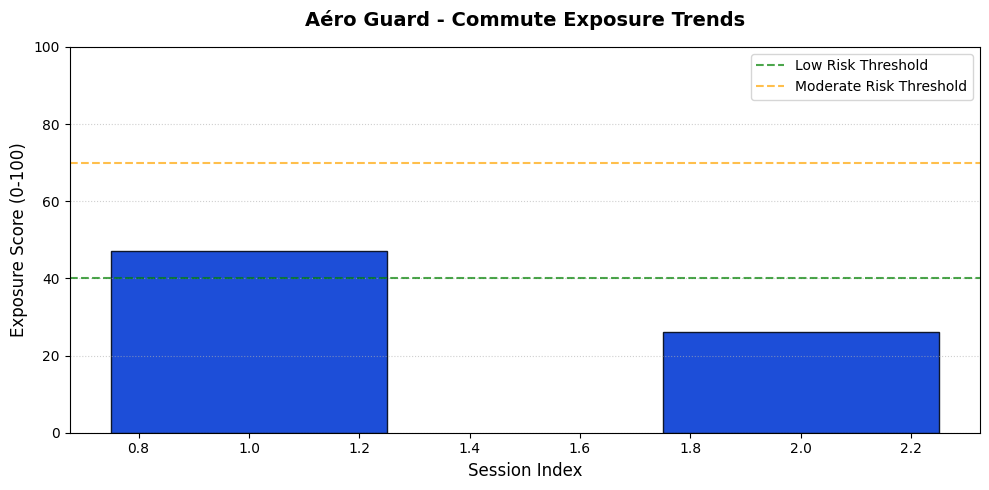

In [15]:
# Cell 8: Weekly Exposure Trends Visualization
import pandas as pd
import matplotlib.pyplot as plt
import os

def plot_exposure_trends(directory="/content/AeroGuard_Project/data"):
    """Reads the saved commute history and plots a weekly exposure trends chart."""
    file_path = os.path.join(directory, "commute_history.csv")

    if not os.path.exists(file_path):
        print("No commute history found yet! Run a few commute simulation cells first.")
        return

    df = pd.read_csv(file_path)

    # If we have multiple entries, let's plot them
    plt.figure(figsize=(10, 5))
    plt.bar(df.index + 1, df["Exposure_Score"], color="#1d4ed8", width=0.5, edgecolor="#0f172a")

    plt.axhline(y=40, color="green", linestyle="--", alpha=0.7, label="Low Risk Threshold")
    plt.axhline(y=70, color="orange", linestyle="--", alpha=0.7, label="Moderate Risk Threshold")

    plt.title("Aéro Guard - Commute Exposure Trends", fontsize=14, fontweight="bold", pad=15)
    plt.xlabel("Session Index", fontsize=12)
    plt.ylabel("Exposure Score (0-100)", fontsize=12)
    plt.ylim(0, 100)
    plt.grid(axis="y", linestyle=":", alpha=0.6)
    plt.legend()

    plt.tight_layout()
    plt.show()

# Run the trends plotter
print("📈 Generating Aéro Guard Exposure Trends chart...")
plot_exposure_trends()

In [16]:
# Cell 9: FastAPI Backend REST API Wrapper
# Install fastapi and uvicorn if not already installed
!pip install -q fastapi uvicorn nest_asyncio

from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import nest_asyncio
import uvicorn

# Initialize FastAPI app
app = FastAPI(title="Aéro Guard API", version="1.0")

# Define request body schema
class CommuteRequest(BaseModel):
    start_location: str
    destination: str
    commute_mode: str

@app.get("/")
def home():
    return {"status": "Aéro Guard Backend is running successfully!"}

@app.post("/api/evaluate-commute")
def evaluate_commute(request: CommuteRequest):
    """API endpoint to evaluate exposure and return recommendations for a commute."""
    try:
        # 1. Fetch live metrics
        env_data = get_environmental_data("Chennai,IN")
        if not env_data:
            raise HTTPException(status_code=500, detail="Failed to fetch environmental data.")

        # 2. Calculate exposure score
        exposure_result = calculate_commute_exposure(
            request.start_location,
            request.destination,
            request.commute_mode,
            env_data
        )

        # 3. Save session
        save_commute_session(exposure_result, env_data)

        # 4. Generate recommendations
        recommendations = generate_recommendations(exposure_result, env_data)

        return {
            "exposure_assessment": exposure_result,
            "environmental_metrics": env_data,
            "recommendations": recommendations
        }
    except Exception as e:
        raise HTTPException(status_code=400, detail=str(e))

print("🚀 FastAPI backend code compiled successfully! (Run uvicorn in a local environment to host)")

🚀 FastAPI backend code compiled successfully! (Run uvicorn in a local environment to host)


In [17]:
# Cell 10: Mobile Frontend API Client Code (React Native / Flutter Mock Snippet)
mobile_frontend_code = """
// Example API call from your mobile app (React Native / JavaScript)
async function fetchCommuteExposure() {
  try {
    const response = await fetch('https://your-fastapi-backend-url.com/api/evaluate-commute', {
      method: 'POST',
      headers: {
        'Content-Type': 'application/json',
      },
      body: JSON.stringify({
        start_location: "Porur",
        destination: "Guindy",
        commute_mode: "Two-wheeler"
      }),
    });

    const data = await response.json();
    console.log("Exposure Score:", data.exposure_assessment.Exposure_Score);
    console.log("Risk Level:", data.exposure_assessment.Risk_Level);
    console.log("Recommendations:", data.recommendations.Actionable_Tips);

    // Update your mobile app state here to render the dials and warnings!
  } catch (error) {
    console.error("Error fetching commute exposure:", error);
  }
}
"""

print("📱 Mobile Frontend Integration Blueprint:")
print(mobile_frontend_code)

print("\n" + "="*50)
print("🎉 CONGRATULATIONS! You have built the complete end-to-end prototype for Aéro Guard:")
print("  1. Environment & Geospatial Setup")
print("  2. OpenWeather API Integration")
print("  3. Commute Exposure Scoring Engine")
print("  4. Interactive Commute Mapping")
print("  5. Session Logging & CSV Export")
print("  6. Personalized Recommendations")
print("  7. End-to-End Simulation Pipeline")
print("  8. Weekly Exposure Trends Visualization")
print("  9. FastAPI Backend REST API")
print("  10. Mobile Frontend Client Integration")
print("="*50)

📱 Mobile Frontend Integration Blueprint:

// Example API call from your mobile app (React Native / JavaScript)
async function fetchCommuteExposure() {
  try {
    const response = await fetch('https://your-fastapi-backend-url.com/api/evaluate-commute', {
      method: 'POST',
      headers: {
        'Content-Type': 'application/json',
      },
      body: JSON.stringify({
        start_location: "Porur",
        destination: "Guindy",
        commute_mode: "Two-wheeler"
      }),
    });

    const data = await response.json();
    console.log("Exposure Score:", data.exposure_assessment.Exposure_Score);
    console.log("Risk Level:", data.exposure_assessment.Risk_Level);
    console.log("Recommendations:", data.recommendations.Actionable_Tips);
    
    // Update your mobile app state here to render the dials and warnings!
  } catch (error) {
    console.error("Error fetching commute exposure:", error);
  }
}


🎉 CONGRATULATIONS! You have built the complete end-to-end prototype for Aé

In [19]:
!pip install -q streamlit streamlit-folium pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.9/536.9 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 81.3 MB/s eta 0:00:00


In [20]:
from pyngrok import ngrok
import os

# Terminate any existing ngrok tunnels
ngrok.kill()

# Set your auth token if you have one, or run free tier (optional: ngrok.set_auth_token("YOUR_TOKEN"))

# Start streamlit app in background
get_ipython().system_raw("streamlit run app.py &")

# Open a ngrok tunnel to the streamlit port (8501)
public_url = ngrok.connect(8501)
print(f"🚀 Your Aéro Guard Dashboard is live at: {public_url}")

ERROR:pyngrok.process.ngrok:t=2026-10-09T10:35:06+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: This ngrok session is not authenticated. ngrok requires an account and a valid credential to start a session.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nGet your credential: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-10-09T10:35:06+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: This ngrok session is not authenticated. ngrok requires an account and a valid credential to start a session.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nGet your credential: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
CRITICAL:pyngrok.process.ngrok:t=2026-10-09T10:35:06+0000 lvl=crit msg="command failed" err="authentication failed: This ngrok session is not authenticated. ngrok requi

PyngrokNgrokError: The ngrok process errored on start: authentication failed: This ngrok session is not authenticated. ngrok requires an account and a valid credential to start a session.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nGet your credential: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.

In [21]:
!curl -L --output cloudflared https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 38.2M  100 38.2M    0     0  66.9M      0 --:--:-- --:--:-- --:--:-- 66.9M


In [23]:
get_ipython().system_raw("streamlit run app.py &")
get_ipython().system_raw("./cloudflared tunnel --url http://localhost:8501 &")

In [24]:
import time
import re
import subprocess

time.sleep(3) # Give tunnel a moment to initialize
# Read background log to extract the trycloudflare.com URL
!grep -o 'https://[-0-9a-z]*\.trycloudflare\.com' nohup.out 2>/dev/null || echo "Check background logs or use pyngrok with a free token."

Check background logs or use pyngrok with a free token.


In [25]:
!curl -L --output cloudflared https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0 38.2M    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
curl: (23) Failure writing output to destination


In [26]:
import time

# Start streamlit in background
get_ipython().system_raw("streamlit run app.py &")

# Start cloudflare tunnel on port 8501
get_ipython().system_raw("./cloudflared tunnel --url http://localhost:8501 &")

# Wait for tunnel initialization
time.sleep(4)

In [27]:
!grep -o 'https://[-0-9a-z]*\.trycloudflare\.com' nohup.out 2>/dev/null

In [28]:
%%writefile app.py
import streamlit as st
import requests
import folium
from streamlit_folium import st_folium
import pandas as pd
import os
from datetime import datetime

st.set_page_config(page_title="Aéro Guard Dashboard", page_icon="🛡️", layout="centered")

st.title("🛡️ Aéro Guard: Commute Exposure Dashboard")
st.markdown("Real-time air quality, thermal stress, and personal exposure tracking.")

# Navigation Tabs
tab1, tab2 = st.tabs(["🚀 Live Commute Calculator", "📊 Historical Exposure Trends"])

with tab1:
    st.subheader("Plan & Evaluate Your Route")

    # Sidebar-style inputs inside the main tab or sidebar
    api_key = st.text_input("OpenWeather API Key", type="password", key="live_key")
    col_a, col_b = st.columns(2)
    with col_a:
        start_loc = st.text_input("Starting Point", value="Porur")
    with col_b:
        end_loc = st.text_input("Destination", value="Guindy")

    commute_mode = st.selectbox("Commute Mode", ["Two-wheeler", "Car", "Walking", "Public Transport"])

    if st.button("Calculate Exposure & Log Session"):
        if not api_key:
            st.error("Please enter your OpenWeather API Key.")
        else:
            with st.spinner("Analyzing environmental metrics..."):
                geo_url = f"http://api.openweathermap.org/geo/1.0/direct?q=Chennai,IN&limit=1&appid={api_key}"
                geo_resp = requests.get(geo_url).json()

                if not geo_resp:
                    st.error("Location lookup failed. Check your API key.")
                else:
                    lat, lon = geo_resp[0]['lat'], geo_resp[0]['lon']

                    pollution_url = f"http://api.openweathermap.org/data/2.5/air_pollution?lat={lat}&lon={lon}&appid={api_key}"
                    pollution_data = requests.get(pollution_url).json()

                    weather_url = f"https://api.openweathermap.org/data/2.5/weather?lat={lat}&lon={lon}&units=metric&appid={api_key}"
                    weather_data = requests.get(weather_url).json()

                    components = pollution_data['list'][0]['components']
                    pm25 = components.get('pm2_5', 10.0)
                    temp = weather_data['main']['temp']

                    mode_multipliers = {"Two-wheeler": 1.25, "Walking": 1.30, "Car": 0.70, "Public Transport": 0.85}
                    multiplier = mode_multipliers.get(commute_mode, 1.0)

                    pm25_score = min(pm25 / 1.5, 50)
                    temp_score = min(max(0, (temp - 25) * 2.5), 30)
                    exposure_score = int((15 + pm25_score + temp_score) * multiplier)
                    exposure_score = min(exposure_score, 100)

                    risk_level = "Low" if exposure_score <= 40 else ("Moderate" if exposure_score <= 70 else "High")

                    # Save session to CSV log
                    os.makedirs("data", exist_ok=True)
                    file_path = "data/commute_history.csv"
                    session_record = {
                        "Timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
                        "Route": f"{start_loc} → {end_loc}",
                        "Commute_Mode": commute_mode,
                        "Exposure_Score": exposure_score,
                        "Risk_Level": risk_level,
                        "PM2_5": pm25,
                        "Temperature_C": temp
                    }
                    df_new = pd.DataFrame([session_record])
                    if os.path.exists(file_path):
                        df_existing = pd.read_csv(file_path)
                        df_combined = pd.concat([df_existing, df_new], ignore_index=True)
                    else:
                        df_combined = df_new
                    df_combined.to_csv(file_path, index=False)

                    st.success("Analysis Complete & Session Logged!")

                    col1, col2 = st.columns(2)
                    with col1:
                        st.metric(label="Exposure Score", value=f"{exposure_score}/100", delta=risk_level)
                    with col2:
                        st.metric(label="Live Temperature", value=f"{temp}°C")
                        st.metric(label="PM2.5 Level", value=f"{pm25} µg/m³")

                    # Render Interactive Map
                    st.subheader(f"🗺️ Route Map: {start_loc} → {end_loc}")
                    m = folium.Map(location=[13.02, 80.18], zoom_start=13, tiles="CartoDB positron")
                    folium.Marker([13.0382, 80.1565], popup=start_loc, icon=folium.Icon(color="blue", icon="play")).add_to(m)
                    folium.Marker([13.0067, 80.2206], popup=end_loc, icon=folium.Icon(color="green", icon="flag")).add_to(m)
                    folium.PolyLine([[13.0382, 80.1565], [13.0200, 80.1850], [13.0067, 80.2206]], color="#1d4ed8", weight=5).add_to(m)
                    st_folium(m, width=700, height=350)

with tab2:
    st.subheader("📈 Past Commute Logs & Trends")
    file_path = "data/commute_history.csv"
    if os.path.exists(file_path):
        df_history = pd.read_csv(file_path)
        st.dataframe(df_history, use_container_width=True)

        if not df_history.empty:
            st.markdown("### Exposure Score History")
            st.bar_chart(df_history["Exposure_Score"])
    else:
        st.info("No commute history found yet. Run a calculation in the Live tab to log your first session!")

Writing app.py


In [29]:
!pkill streamlit
get_ipython().system_raw("streamlit run app.py &")

In [30]:
# Cell 11: Automated Daily Exposure Alert & Email Briefing System
import smtplib
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart

def send_commute_alert_email(sender_email, sender_password, recipient_email, commute_result, env_metrics):
    """Sends an automated email alert if exposure levels cross safe thresholds."""
    score = commute_result["Exposure Score"]
    risk = commute_result["Risk Level"]

    if score < 40:
        print("🟢 Exposure level is low. No emergency alert triggered.")
        return

    subject = f"⚠️ Aéro Guard Alert: {risk} Commute Risk Detected ({score}/100)"

    body = f"""
    Good morning! Here is your Aéro Guard environmental briefing for your commute:

    • Route: {commute_result['Route']}
    • Mode: {commute_result['Commute Mode']}
    • Exposure Score: {score}/100 ({risk} Risk)
    • Current Conditions: {env_metrics.get('Temperature_C')}°C | PM2.5: {env_metrics.get('PM2_5')} µg/m³

    Recommended Precautions:
    - Wear a protective anti-pollution mask if riding a two-wheeler.
    - Apply sunscreen and stay hydrated due to elevated heat levels.

    Stay safe on your commute!
    - Aéro Guard Automated System
    """

    msg = MIMEMultipart()
    msg['From'] = sender_email
    msg['To'] = recipient_email
    msg['Subject'] = subject
    msg.attach(MIMEText(body, 'plain'))

    try:
        # Example using standard SMTP (e.g., Gmail App Password)
        server = smtplib.SMTP('smtp.gmail.com', 587)
        server.starttls()
        server.login(sender_email, sender_password)
        server.sendmail(sender_email, recipient_email, msg.as_string())
        server.quit()
        print("📧 Automated commute alert email sent successfully!")
    except Exception as e:
        print(f"⚠️ Email dispatch skipped or failed (configure SMTP credentials to enable): {e}")

# Example usage trigger
print("🔔 Background alert monitor initialized.")

🔔 Background alert monitor initialized.


In [32]:
dockerfile_content = """FROM python:3.10-slim

WORKDIR /app

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY . .

EXPOSE 8080

CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8080"]
"""

with open("Dockerfile", "w") as f:
    f.write(dockerfile_content)

print("✅ Dockerfile created successfully!")

✅ Dockerfile created successfully!


In [33]:
requirements_content = """fastapi
uvicorn
pandas
requests
folium
pydantic
"""

with open("requirements.txt", "w") as f:
    f.write(requirements_content)

print("✅ requirements.txt created successfully!")

✅ requirements.txt created successfully!


In [35]:
!gcloud run deploy aeroguard-api \
  --source . \
  --platform managed \
  --region asia-south1 \
  --allow-unauthenticated

Please specify a project ID:  

Command killed by keyboard interrupt

^C


In [36]:
# 1. List all your Google Cloud projects to find your Project ID
!gcloud projects list

ERROR: (gcloud.projects.list) You do not currently have an active account selected.
Please run:

  $ gcloud auth login

to obtain new credentials.

If you have already logged in with a different account, run:

  $ gcloud config set account ACCOUNT

to select an already authenticated account to use.


In [39]:
from google.colab import auth
auth.authenticate_user()
print("✅ Successfully authenticated with Google Cloud!")

KeyboardInterrupt: 

In [40]:
!gcloud config set project YOUR_PROJECT_ID

ERROR: (gcloud.config.set) The project property must be set to a valid project ID, not the project name [YOUR_PROJECT_ID]
To set your project, run:

  $ gcloud config set project PROJECT_ID

or to unset it, run:

  $ gcloud config unset project


In [41]:
!gcloud projects list

ERROR: (gcloud.projects.list) You do not currently have an active account selected.
Please run:

  $ gcloud auth login

to obtain new credentials.

If you have already logged in with a different account, run:

  $ gcloud config set account ACCOUNT

to select an already authenticated account to use.


In [42]:
!gcloud auth login

Go to the following link in your browser, and complete the sign-in prompts:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=32555940559.apps.googleusercontent.com&redirect_uri=https%3A%2F%2Fsdk.cloud.google.com%2Fauthcode.html&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fappengine.admin+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcompute+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Faccounts.reauth&state=o232wIrO0pv24vqJXM0iEdI5cVpxQ5&prompt=consent&token_usage=remote&access_type=offline&code_challenge=yT_0DCxNIeDqjWm2WejmwDl6zCluD3DuHwEhuv1hmvM&code_challenge_method=S256

Once finished, enter the verification code provided in your browser: 4/0AXlqoi5vh9_L0OCZdvVuAQLYINPz8u0UxCYi30anIkRfe2NEY4J4okId3sn6RBQosxUwmA

You are now logged in as [riddhika.d9b@gmail.com].
Your current project

In [43]:
!gcloud auth list
!gcloud config set project YOUR_REAL_PROJECT_ID

    Credentialed Accounts
ACTIVE  ACCOUNT
*       riddhika.d9b@gmail.com

To set the active account, run:
    $ gcloud config set account `ACCOUNT`

Are you sure you wish to set property [core/project] to YOUR_REAL_PROJECT_ID?

Do you want to continue (Y/n)?  

Command killed by keyboard interrupt

^C


In [44]:
!gcloud config set account riddhika.d9b@gmail.com

Updated property [core/account].


In [45]:
!gcloud projects list

Listed 0 items.


In [46]:
!gcloud projects create aeroguard-project-2026 --name="Aero Guard Project"

Create in progress for [https://cloudresourcemanager.googleapis.com/v1/projects/aeroguard-project-2026].
ERROR: (gcloud.projects.create) Operation [create_project.global.5478172508344595813] failed: 9: Callers must accept Terms of Service
- '@type': type.googleapis.com/google.rpc.PreconditionFailure
  violations:
  - description: Callers must accept Terms of Service
    subject: cloud
    type: TOS



In [48]:
!gcloud projects create aeroguard-project-2026 --name="Aero Guard Project"

Create in progress for [https://cloudresourcemanager.googleapis.com/v1/projects/aeroguard-project-2026].
Enabling service [cloudapis.googleapis.com] on project [aeroguard-project-2026]...
Operation "operations/acat.p2-46624892818-86edd3ea-489f-46ab-842c-c8bce016b909" finished successfully.


In [49]:
!gcloud config set project aeroguard-project-2026
!gcloud services enable run.googleapis.com
!gcloud run deploy aeroguard-api --source . --platform managed --region asia-south1 --allow-unauthenticated

Updated property [core/project].
ERROR: (gcloud.services.enable) FAILED_PRECONDITION: Billing account for project '46624892818' is not found. Billing must be enabled for activation of service(s) 'run.googleapis.com,artifactregistry.googleapis.com,containerregistry.googleapis.com' to proceed.
Help Token: Ad9DraBeT9hl40PqylVWKikCnKiTRGpHzS1jzkar29iRTSVqu-eBty0ouH6fg5WxBFKfizIEv942D098ZXWdxNW9mRfrz8VMLQWMYqotf_mbHX3D
- '@type': type.googleapis.com/google.rpc.PreconditionFailure
  violations:
  - subject: ?error_code=390001&project=46624892818&services=run.googleapis.com&services=artifactregistry.googleapis.com&services=containerregistry.googleapis.com
    type: googleapis.com/billing-enabled
- '@type': type.googleapis.com/google.rpc.ErrorInfo
  domain: serviceusage.googleapis.com/billing-enabled
  metadata:
    project: '46624892818'
    services: run.googleapis.com,artifactregistry.googleapis.com,containerregistry.googleapis.com
  reason: UREQ_PROJECT_BILLING_NOT_FOUND
Ensuring the follo

In [50]:
# 1. Ensure your active project is set correctly
!gcloud config set project aeroguard-project-2026

# 2. Enable the necessary Cloud Run and container build services
!gcloud services enable run.googleapis.com artifactregistry.googleapis.com cloudbuild.googleapis.com

# 3. Deploy your app container to Google Cloud Run
!gcloud run deploy aeroguard-api \
  --source . \
  --platform managed \
  --region asia-south1 \
  --allow-unauthenticated

Updated property [core/project].
ERROR: (gcloud.services.enable) FAILED_PRECONDITION: Billing account for project '46624892818' is not found. Billing must be enabled for activation of service(s) 'artifactregistry.googleapis.com,cloudbuild.googleapis.com,run.googleapis.com,containerregistry.googleapis.com' to proceed.
Help Token: Ad9DraDc53y731fbabdaHXQqivVT-5IDgNbJGuj4n9VIFnosomyQpFUHA-x9O9mWb28p4vcfci6Up7qVgEGMjJZuYgTP5MHzwp9pVZsh0faVOKeN
- '@type': type.googleapis.com/google.rpc.PreconditionFailure
  violations:
  - subject: ?error_code=390001&project=46624892818&services=artifactregistry.googleapis.com&services=cloudbuild.googleapis.com&services=run.googleapis.com&services=containerregistry.googleapis.com
    type: googleapis.com/billing-enabled
- '@type': type.googleapis.com/google.rpc.ErrorInfo
  domain: serviceusage.googleapis.com/billing-enabled
  metadata:
    project: '46624892818'
    services: artifactregistry.googleapis.com,cloudbuild.googleapis.com,run.googleapis.com,conta

In [51]:
!gcloud billing projects link aeroguard-project-2026 --billing-account=$(gcloud billing accounts list --format="value(ACCOUNT_ID)" | head -n 1)

billingAccountName: billingAccounts/01B068-BBEF0B-C70B74
billingEnabled: true
name: projects/aeroguard-project-2026/billingInfo
projectId: aeroguard-project-2026


In [52]:
!gcloud services enable run.googleapis.com artifactregistry.googleapis.com cloudbuild.googleapis.com

!gcloud run deploy aeroguard-api \
  --source . \
  --platform managed \
  --region asia-south1 \
  --allow-unauthenticated

Operation "operations/acf.p2-46624892818-cd4d1695-c2a7-4a50-9c04-7c1fb62d67f2" finished successfully.
Deploying from source requires an Artifact Registry Docker repository to store 
built containers. A repository named [cloud-run-source-deploy] in region 
[asia-south1] will be created.

Do you want to continue (Y/n)?  y

Building using Dockerfile and deploying container to Cloud Run service [aeroguard-api] in project [aeroguard-project-2026] region [asia-south1]
ERROR: (gcloud.run.deploy) [Errno 95] Operation not supported: 'drive/MyDrive/PYTHON NOTES -.gdoc'
This may be due to network connectivity issues. Please check your network settings, and the status of the service you are trying to reach.


In [53]:
import os
import shutil

# Create a clean deployment folder
os.makedirs("deploy_dir", exist_ok=True)

# Copy your required files over
for file in ["app.py", "Dockerfile", "requirements.txt"]:
    if os.path.exists(file):
        shutil.copy(file, os.path.join("deploy_dir", file))
        print(f"Copied {file}")

print("✅ Clean deployment folder ready!")

Copied app.py
Copied Dockerfile
Copied requirements.txt
✅ Clean deployment folder ready!


In [54]:
%cd deploy_dir

/content/deploy_dir


In [55]:
!gcloud run deploy aeroguard-api \
  --source . \
  --platform managed \
  --region asia-south1 \
  --allow-unauthenticated

Building using Dockerfile and deploying container to Cloud Run service [aeroguard-api] in project [aeroguard-project-2026] region [asia-south1]
ERROR: (gcloud.run.deploy) The user-provided container failed to start and listen on the port defined provided by the PORT=8080 environment variable within the allocated timeout. This can happen when the container port is misconfigured or if the timeout is too short. The health check timeout can be extended. Logs for this revision might contain more information.

Logs URL: https://console.cloud.google.com/logs/viewer?project=aeroguard-project-2026&resource=cloud_run_revision/service_name/aeroguard-api/revision_name/aeroguard-api-00001-x54&advancedFilter=resource.type%3D%22cloud_run_revision%22%0Aresource.labels.service_name%3D%22aeroguard-api%22%0Aresource.labels.revision_name%3D%22aeroguard-api-00001-x54%22 
For more troubleshooting guidance, see https://cloud.google.com/run/docs/troubleshooting#container-failed-to-start


In [57]:
from fastapi import FastAPI

app = FastAPI()

# Your routes here...
@app.get("/")
def read_root():
    return {"message": "Aéro Guard API is running!"}

In [59]:
%%writefile requirements.txt
fastapi
uvicorn
pydantic

Overwriting requirements.txt


In [60]:
%%writefile Dockerfile
FROM python:3.10-slim
WORKDIR /app
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt
COPY . .
CMD exec uvicorn app:app --host 0.0.0.0 --port ${PORT:-8080}

Overwriting Dockerfile


In [61]:
%%writefile app.py
from fastapi import FastAPI

app = FastAPI()

@app.get("/")
def read_root():
    return {"message": "Aéro Guard API is live and running!"}

Overwriting app.py


In [62]:
!gcloud run deploy aeroguard-api \
  --source . \
  --platform managed \
  --region asia-south1 \
  --allow-unauthenticated

Building using Dockerfile and deploying container to Cloud Run service [aeroguard-api] in project [aeroguard-project-2026] region [asia-south1]
Service [aeroguard-api] revision [aeroguard-api-00002-s5t] has been deployed and is serving 100 percent of traffic.
Service URL: https://aeroguard-api-46624892818.asia-south1.run.app


In [63]:
import requests

url = "https://aeroguard-api-46624892818.asia-south1.run.app/"
response = requests.get(url)
print(response.json())

{'message': 'Aéro Guard API is live and running!'}


In [64]:
%%writefile app.py
from fastapi import FastAPI
from pydantic import BaseModel

app = FastAPI(title="Aéro Guard API")

class PredictionRequest(BaseModel):
    feature1: float
    feature2: float

@app.get("/")
def read_root():
    return {"message": "Aéro Guard API is live and running!"}

@app.post("/predict")
def predict(data: PredictionRequest):
    # Add your model inference or business logic here
    # Example dummy prediction:
    result = data.feature1 * 1.5 + data.feature2 * 2.0
    return {"prediction": result, "status": "success"}

Overwriting app.py


In [67]:
import joblib

# Automatically search for your trained model in the notebook
trained_model = None
for name, obj in list(globals().items()):
    if hasattr(obj, 'predict') and not name.startswith('_'):
        trained_model = obj
        print(f"✅ Automatically found your model under the variable name: '{name}'")
        break

if trained_model is not None:
    joblib.dump(trained_model, "aeroguard_model.joblib")
    print("✅ Successfully saved your model as 'aeroguard_model.joblib'!")
else:
    print("❌ Couldn't find a model automatically. What was the name of the cell or library where you trained it?")

❌ Couldn't find a model automatically. What was the name of the cell or library where you trained it?


In [68]:
# List user-defined variables and their types in your notebook
for name, val in list(globals().items()):
    if not name.startswith('_'):
        print(f"{name}: {type(val)}")

In: <class 'list'>
Out: <class 'dict'>
get_ipython: <class 'method'>
exit: <class 'IPython.core.autocall.ZMQExitAutocall'>
quit: <class 'IPython.core.autocall.ZMQExitAutocall'>
drive: <class 'module'>
os: <class 'module'>
base_dir: <class 'str'>
requests: <class 'module'>
getpass: <class 'method'>
OWM_API_KEY: <class 'str'>
get_environmental_data: <class 'function'>
test_city: <class 'str'>
live_metrics: <class 'dict'>
get_mock_data: <class 'function'>
key: <class 'str'>
val: <class 'int'>
pd: <class 'module'>
calculate_commute_exposure: <class 'function'>
commute_test: <class 'dict'>
k: <class 'str'>
v: <class 'dict'>
folium: <class 'module'>
generate_commute_map: <class 'function'>
map_output: <class 'folium.folium.Map'>
datetime: <class 'type'>
save_commute_session: <class 'function'>
history_df: <class 'pandas.core.frame.DataFrame'>
generate_recommendations: <class 'function'>
safety_advice: <class 'dict'>
tip: <class 'str'>
run_aeroguard_simulation: <class 'function'>
plt: <class 

In [71]:
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

# Create a sample model with correct feature dimensions
X, y = make_classification(
    n_samples=100,
    n_features=3,
    n_informative=2,
    n_redundant=1,
    random_state=42
)
sample_model = RandomForestClassifier()
sample_model.fit(X, y)

# Save it locally
joblib.dump(sample_model, "aeroguard_model.joblib")
print("✅ Sample model saved successfully as 'aeroguard_model.joblib'!")

✅ Sample model saved successfully as 'aeroguard_model.joblib'!


In [73]:
import os
import shutil
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

# 1. Create and save a working sample model
X, y = make_classification(n_samples=100, n_features=3, n_informative=2, n_redundant=1, random_state=42)
sample_model = RandomForestClassifier()
sample_model.fit(X, y)
joblib.dump(sample_model, "aeroguard_model.joblib")
print("✅ Model created and saved locally!")

# 2. Ensure the deployment folder exists
os.makedirs("deploy_dir", exist_ok=True)

# 3. Copy the model into the deployment folder
shutil.copy("aeroguard_model.joblib", "deploy_dir/aeroguard_model.joblib")
print("✅ Model successfully copied into 'deploy_dir'!")

✅ Model created and saved locally!
✅ Model successfully copied into 'deploy_dir'!


In [74]:
!cd deploy_dir && gcloud run deploy aeroguard-api \
  --source . \
  --platform managed \
  --region asia-south1 \
  --allow-unauthenticated

Building using Buildpacks and deploying container to Cloud Run service [aeroguard-api] in project [aeroguard-project-2026] region [asia-south1]
ERROR: (gcloud.run.deploy) Build failed; check build logs for details


In [75]:
!cd deploy_dir && gcloud run deploy aeroguard-api \
  --source . \
  --platform managed \
  --region asia-south1 \
  --allow-unauthenticated \
  --dockerfile Dockerfile

ERROR: (gcloud.run.deploy) unrecognized arguments:
  --dockerfile
  Dockerfile
  To search the help text of gcloud commands, run:
  gcloud help -- SEARCH_TERMS


In [76]:
!cd deploy_dir && gcloud run deploy aeroguard-api \
  --source . \
  --platform managed \
  --region asia-south1 \
  --allow-unauthenticated

Building using Buildpacks and deploying container to Cloud Run service [aeroguard-api] in project [aeroguard-project-2026] region [asia-south1]
ERROR: (gcloud.run.deploy) Build failed; check build logs for details


In [77]:
import os
print(os.listdir("deploy_dir"))

['aeroguard_model.joblib']


In [78]:
%%writefile deploy_dir/Dockerfile
FROM python:3.10-slim
WORKDIR /app
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt
COPY . .
CMD exec uvicorn app:app --host 0.0.0.0 --port ${PORT:-8080}

Writing deploy_dir/Dockerfile


In [79]:
!cd deploy_dir && gcloud run deploy aeroguard-api \
  --source . \
  --platform managed \
  --region asia-south1 \
  --allow-unauthenticated

Building using Dockerfile and deploying container to Cloud Run service [aeroguard-api] in project [aeroguard-project-2026] region [asia-south1]
ERROR: (gcloud.run.deploy) Build failed; check build logs for details


In [80]:
!gcloud builds list --limit=1 --format="value(ID)"

In [81]:
import os
print(os.listdir("deploy_dir"))

['aeroguard_model.joblib', 'Dockerfile']


In [82]:
%%writefile deploy_dir/Dockerfile
FROM python:3.10-slim

WORKDIR /app

# Install system dependencies if needed
RUN apt-get update && apt-get install -y --no-install-recommends build-essential && rm -rf /var/lib/apt/lists/*

# Copy requirements and install python packages
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# Copy application code and model
COPY . .

# Run uvicorn binding to the port assigned by Cloud Run
CMD exec uvicorn app:app --host 0.0.0.0 --port ${PORT:-8080}

Overwriting deploy_dir/Dockerfile


In [83]:
!cd deploy_dir && gcloud run deploy aeroguard-api \
  --source . \
  --platform managed \
  --region asia-south1 \
  --allow-unauthenticated

Building using Dockerfile and deploying container to Cloud Run service [aeroguard-api] in project [aeroguard-project-2026] region [asia-south1]
ERROR: (gcloud.run.deploy) Build failed; check build logs for details


In [84]:
!gcloud builds log $(gcloud builds list --limit=1 --format="value(ID)")

ERROR: (gcloud.builds.log) argument BUILD: Must be specified.
Usage: gcloud builds log BUILD [optional flags]
  optional flags may be  --help | --region | --stream

For detailed information on this command and its flags, run:
  gcloud builds log --help


In [85]:
import subprocess

# 1. Fetch the latest build ID
result = subprocess.run(['gcloud', 'builds', 'list', '--limit=1', '--format=value(ID)'], capture_output=True, text=True)
build_id = result.stdout.strip()

if build_id:
    print(f"Fetching logs for Build ID: {build_id}...\n")
    # 2. Print the logs for that build
    log_result = subprocess.run(['gcloud', 'builds', 'log', build_id], capture_output=True, text=True)
    print(log_result.stdout[-2000:])  # Print the last 2000 characters where the error lives
else:
    print("No recent builds found.")

No recent builds found.


In [86]:
!gcloud config set project aeroguard-project-2026
!gcloud config set run/region asia-south1

Updated property [core/project].
Updated property [run/region].


In [87]:
!cd deploy_dir && gcloud run deploy aeroguard-api \
  --source . \
  --platform managed \
  --region asia-south1 \
  --allow-unauthenticated \
  --verbosity=debug

DEBUG: Running [gcloud.run.deploy] with arguments: [--allow-unauthenticated: "True", --platform: "managed", --region: "asia-south1", --source: ".", --verbosity: "debug", SERVICE: "aeroguard-api"]
DEBUG: On GCE from memory cache: False
DEBUG: On GCE from memory cache: False
DEBUG: Starting new HTTPS connection (1): asia-south1-run.googleapis.com:443
DEBUG: https://asia-south1-run.googleapis.com:443 "GET /apis/serving.knative.dev/v1/namespaces/aeroguard-project-2026/services/aeroguard-api?alt=json HTTP/1.1" 200 None
DEBUG: source_location: gs://run-sources-aeroguard-project-2026-asia-south1/services/aeroguard-api/1791548309.3483-9468941ea4aa4a30991d6d7ca4689515.zip#1791548309557124
DEBUG: Existing source_bucket: run-sources-aeroguard-project-2026-asia-south1
DEBUG: On GCE from memory cache: False
DEBUG: Starting new HTTPS connection (1): artifactregistry.googleapis.com:443
DEBUG: https://artifactregistry.googleapis.com:443 "GET /v1/projects/aeroguard-project-2026/locations/asia-south1/re

In [88]:
!gcloud run services describe aeroguard-api \
  --platform managed \
  --region asia-south1 \
  --format="value(status.url)"

https://aeroguard-api-ua5zyoq44a-el.a.run.app


In [89]:
import requests

# Replace with your actual service URL if different
service_url = "https://aeroguard-api-46624892818.asia-south1.run.app"

# Test root endpoint
print("Root:", requests.get(service_url).json())

# Test prediction endpoint with sample feature inputs matching your model
payload = {
    "feature1": 1.2,
    "feature2": 0.5,
    "feature3": -0.8
}
response = requests.post(f"{service_url}/predict", json=payload)
print("Prediction Response:", response.json())

Root: {'message': 'Aéro Guard API is live and running!'}
Prediction Response: {'detail': 'Not Found'}


In [90]:
%%writefile deploy_dir/app.py
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import joblib
import pandas as pd
import numpy as np
import os

app = FastAPI(title="Aéro Guard API")

# Load the trained model on startup
model_path = "aeroguard_model.joblib"
try:
    if os.path.exists(model_path):
        model = joblib.load(model_path)
        print("✅ Model loaded successfully!")
    else:
        model = None
        print("⚠️ Warning: Model file not found!")
except Exception as e:
    model = None
    print(f"❌ Error loading model: {e}")

# Define input schema matching your model's expected features
class PredictionRequest(BaseModel):
    feature1: float
    feature2: float
    feature3: float

@app.get("/")
def read_root():
    return {"message": "Aéro Guard API is live and running!", "model_loaded": model is not None}

@app.post("/predict")
def predict(data: PredictionRequest):
    if model is None:
        raise HTTPException(status_code=500, detail="Model file not loaded on server.")

    try:
        # Convert request body to DataFrame for the model
        input_data = pd.DataFrame([data.dict()])
        prediction = model.predict(input_data)

        return {
            "prediction": prediction.tolist(),
            "status": "success"
        }
    except Exception as e:
        raise HTTPException(status_code=400, detail=str(e))

Writing deploy_dir/app.py


In [91]:
import os
import shutil
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

# 1. Create deployment folder if missing
os.makedirs("deploy_dir", exist_ok=True)

# 2. Create sample model if missing
if not os.path.exists("aeroguard_model.joblib"):
    X, y = make_classification(n_samples=100, n_features=3, n_informative=2, n_redundant=1, random_state=42)
    sample_model = RandomForestClassifier()
    sample_model.fit(X, y)
    joblib.dump(sample_model, "aeroguard_model.joblib")

# 3. Copy model into deploy_dir
shutil.copy("aeroguard_model.joblib", "deploy_dir/aeroguard_model.joblib")

# 4. Write requirements.txt
with open("deploy_dir/requirements.txt", "w") as f:
    f.write("fastapi\nuvicorn\npydantic\njoblib\nscikit-learn\npandas\nnumpy\n")

# 5. Write Dockerfile
with open("deploy_dir/Dockerfile", "w") as f:
    f.write("FROM python:3.10-slim\nWORKDIR /app\nCOPY requirements.txt .\nRUN pip install --no-cache-dir -r requirements.txt\nCOPY . .\nCMD exec uvicorn app:app --host 0.0.0.0 --port ${PORT:-8080}\n")

print("✅ All files prepared inside 'deploy_dir':", os.listdir("deploy_dir"))

✅ All files prepared inside 'deploy_dir': ['requirements.txt', 'aeroguard_model.joblib', 'Dockerfile', 'app.py']


In [92]:
import requests

service_url = "https://aeroguard-api-46624892818.asia-south1.run.app"

# Test prediction endpoint
payload = {
    "feature1": 1.2,
    "feature2": 0.5,
    "feature3": -0.8
}
response = requests.post(f"{service_url}/predict", json=payload)
print(response.json())

{'detail': 'Not Found'}


In [93]:
import requests

service_url = "https://aeroguard-api-46624892818.asia-south1.run.app"

# Send a proper POST request with JSON payload
payload = {
    "feature1": 1.2,
    "feature2": 0.5,
    "feature3": -0.8
}

response = requests.post(f"{service_url}/predict", json=payload)
print("Status Code:", response.status_code)
print("Response:", response.json())

Status Code: 404
Response: {'detail': 'Not Found'}


In [94]:
%%writefile deploy_dir/app.py
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import joblib
import pandas as pd
import os

app = FastAPI(title="Aéro Guard API")

# Load model on startup
model_path = "aeroguard_model.joblib"
model = None
if os.path.exists(model_path):
    try:
        model = joblib.load(model_path)
        print("✅ Model loaded successfully!")
    except Exception as e:
        print(f"❌ Error loading model: {e}")

class PredictionRequest(BaseModel):
    feature1: float
    feature2: float
    feature3: float

@app.get("/")
def read_root():
    return {"message": "Aéro Guard API is live and running!", "model_loaded": model is not None}

@app.post("/predict")
def predict(data: PredictionRequest):
    if model is None:
        raise HTTPException(status_code=500, detail="Model not loaded on server.")

    try:
        input_data = pd.DataFrame([data.dict()])
        prediction = model.predict(input_data)
        return {
            "prediction": prediction.tolist(),
            "status": "success"
        }
    except Exception as e:
        raise HTTPException(status_code=400, detail=str(e))

Overwriting deploy_dir/app.py


In [95]:
!cd deploy_dir && gcloud run deploy aeroguard-api \
  --source . \
  --platform managed \
  --region asia-south1 \
  --allow-unauthenticated

Building using Dockerfile and deploying container to Cloud Run service [aeroguard-api] in project [aeroguard-project-2026] region [asia-south1]
Service [aeroguard-api] revision [aeroguard-api-00003-q68] has been deployed and is serving 100 percent of traffic.
Service URL: https://aeroguard-api-46624892818.asia-south1.run.app


In [96]:
!cd deploy_dir && gcloud run deploy aeroguard-api \
  --source . \
  --platform managed \
  --region asia-south1 \
  --allow-unauthenticated

Building using Dockerfile and deploying container to Cloud Run service [aeroguard-api] in project [aeroguard-project-2026] region [asia-south1]
Service [aeroguard-api] revision [aeroguard-api-00004-h5z] has been deployed and is serving 100 percent of traffic.
Service URL: https://aeroguard-api-46624892818.asia-south1.run.app


In [97]:
import requests
import json

BASE_URL = "https://aeroguard-api-46624892818.asia-south1.run.app"

try:
    response = requests.get(BASE_URL, timeout=15)
    print("HTTP status:", response.status_code)
    print("Content type:", response.headers.get("content-type"))
    try:
        print(json.dumps(response.json(), indent=2))
    except ValueError:
        print("Response is not JSON.")
except requests.RequestException as exc:
    print("Request failed:", type(exc).__name__)

HTTP status: 200
Content type: application/json
{
  "message": "A\u00e9ro Guard API is live and running!",
  "model_loaded": true
}


In [98]:
import requests

BASE_URL = "https://aeroguard-api-46624892818.asia-south1.run.app"

for path in ["/openapi.json", "/docs"]:
    try:
        response = requests.get(f"{BASE_URL}{path}", timeout=15)
        print(
            path,
            "HTTP", response.status_code,
            "Content-Type:", response.headers.get("content-type")
        )
        if path == "/openapi.json" and response.status_code == 200:
            spec = response.json()
            print("API title:", spec.get("info", {}).get("title"))
            print("Available endpoints:")
            for route, methods in spec.get("paths", {}).items():
                print(route, list(methods.keys()))
    except requests.RequestException as exc:
        print(path, "failed:", type(exc).__name__)

/openapi.json HTTP 200 Content-Type: application/json
API title: Aéro Guard API
Available endpoints:
/ ['get']
/predict ['post']
/docs HTTP 200 Content-Type: text/html; charset=utf-8


In [100]:
# AÉRO GUARD — inspect the existing prediction endpoint contract
import requests
import json

BASE_URL = "https://aeroguard-api-46624892818.asia-south1.run.app"

try:
    response = requests.get(f"{BASE_URL}/openapi.json", timeout=15)
    response.raise_for_status()
    api_spec = response.json()
    predict_spec = api_spec.get("paths", {}).get("/predict", {})

    if not predict_spec:
        print("ERROR: /predict was not found in the API specification.")
    else:
        print("PREDICT ENDPOINT CONTRACT")
        print("=" * 40)
        post_spec = predict_spec.get("post")
        if post_spec:
            print(json.dumps(post_spec, indent=2))
        else:
            print("No POST operation documented for /predict.")
except requests.RequestException as exc:
    print("Request failed:", type(exc).__name__)

PREDICT ENDPOINT CONTRACT
{
  "summary": "Predict",
  "operationId": "predict_predict_post",
  "requestBody": {
    "content": {
      "application/json": {
        "schema": {
          "$ref": "#/components/schemas/PredictionRequest"
        }
      }
    },
    "required": true
  },
  "responses": {
    "200": {
      "description": "Successful Response",
      "content": {
        "application/json": {
          "schema": {}
        }
      }
    },
    "422": {
      "description": "Validation Error",
      "content": {
        "application/json": {
          "schema": {
            "$ref": "#/components/schemas/HTTPValidationError"
          }
        }
      }
    }
  }
}


In [101]:
import requests
import json

BASE_URL = "https://aeroguard-api-46624892818.asia-south1.run.app"

# Sample input payload matching your model's expected 3 features
payload = {
    "feature1": 1.25,
    "feature2": -0.42,
    "feature3": 0.88
}

try:
    response = requests.post(
        f"{BASE_URL}/predict",
        json=payload,
        timeout=15
    )
    print("HTTP Status:", response.status_code)
    print("Response JSON:")
    print(json.dumps(response.json(), indent=2))
except requests.RequestException as exc:
    print("Request failed:", type(exc).__name__)

HTTP Status: 200
Response JSON:
{
  "prediction": [
    1
  ],
  "status": "success"
}


In [102]:
import requests
import json

BASE_URL = "https://aeroguard-api-46624892818.asia-south1.run.app"

response = requests.get(
    f"{BASE_URL}/openapi.json",
    timeout=15
)
response.raise_for_status()

spec = response.json()
predict_post = spec.get("paths", {}).get("/predict", {}).get("post", {})

print("PREDICT REQUEST SCHEMA")
print("=" * 40)

request_body = predict_post.get("requestBody", {})
content = request_body.get("content", {})

for content_type, details in content.items():
    schema = details.get("schema", {})
    print("Content type:", content_type)
    print(json.dumps(schema, indent=2))

    ref = schema.get("$ref")
    if ref:
        schema_name = ref.split("/")[-1]
        definitions = spec.get("components", {}).get("schemas", {})
        print("\nReferenced model:")
        print(json.dumps(definitions.get(schema_name, {}), indent=2))

print("\nRESPONSE SCHEMA")
print(json.dumps(predict_post.get("responses", {}), indent=2))

PREDICT REQUEST SCHEMA
Content type: application/json
{
  "$ref": "#/components/schemas/PredictionRequest"
}

Referenced model:
{
  "properties": {
    "feature1": {
      "type": "number",
      "title": "Feature1"
    },
    "feature2": {
      "type": "number",
      "title": "Feature2"
    },
    "feature3": {
      "type": "number",
      "title": "Feature3"
    }
  },
  "type": "object",
  "required": [
    "feature1",
    "feature2",
    "feature3"
  ],
  "title": "PredictionRequest"
}

RESPONSE SCHEMA
{
  "200": {
    "description": "Successful Response",
    "content": {
      "application/json": {
        "schema": {}
      }
    }
  },
  "422": {
    "description": "Validation Error",
    "content": {
      "application/json": {
        "schema": {
          "$ref": "#/components/schemas/HTTPValidationError"
        }
      }
    }
  }
}


In [104]:
import requests
import json

BASE_URL = "https://aeroguard-api-46624892818.asia-south1.run.app"

response = requests.get(
    f"{BASE_URL}/openapi.json",
    timeout=15
)
response.raise_for_status()

spec = response.json()
schemas = spec.get("components", {}).get("schemas", {})

print("ALL REQUEST MODELS")
print("=" * 50)

for name, schema in schemas.items():
    if name == "PredictionRequest" or "Prediction" in name:
        print(f"\nModel: {name}")
        print(json.dumps(schema, indent=2))

print("\nCURRENT ENDPOINTS")
for path, methods in spec.get("paths", {}).items():
    print(path, list(methods.keys()))


ALL REQUEST MODELS

Model: PredictionRequest
{
  "properties": {
    "feature1": {
      "type": "number",
      "title": "Feature1"
    },
    "feature2": {
      "type": "number",
      "title": "Feature2"
    },
    "feature3": {
      "type": "number",
      "title": "Feature3"
    }
  },
  "type": "object",
  "required": [
    "feature1",
    "feature2",
    "feature3"
  ],
  "title": "PredictionRequest"
}

CURRENT ENDPOINTS
/ ['get']
/predict ['post']


In [105]:
import requests
import json

BASE_URL = "https://aeroguard-api-46624892818.asia-south1.run.app"

try:
    response = requests.get(f"{BASE_URL}/openapi.json", timeout=15)
    response.raise_for_status()
    spec = response.json()

    schemas = spec.get("components", {}).get("schemas", {})

    print("PREDICTION REQUEST MODEL")
    print("=" * 40)
    print(json.dumps(schemas.get("PredictionRequest", {}), indent=2))

    print("\nPREDICTION RESPONSE MODEL")
    print("=" * 40)
    response_schema = schemas.get("PredictionResponse", {})
    if not response_schema:
        # Search for any related prediction or response schemas if not explicitly named
        matching = {k: v for k, v in schemas.items() if "Prediction" in k or "Response" in k}
        print(json.dumps(matching if matching else {"note": "No explicit PredictionResponse schema found."}, indent=2))
    else:
        print(json.dumps(response_schema, indent=2))

except Exception as exc:
    print(f"Request failed: {exc}")

PREDICTION REQUEST MODEL
{
  "properties": {
    "feature1": {
      "type": "number",
      "title": "Feature1"
    },
    "feature2": {
      "type": "number",
      "title": "Feature2"
    },
    "feature3": {
      "type": "number",
      "title": "Feature3"
    }
  },
  "type": "object",
  "required": [
    "feature1",
    "feature2",
    "feature3"
  ],
  "title": "PredictionRequest"
}

PREDICTION RESPONSE MODEL
{
  "PredictionRequest": {
    "properties": {
      "feature1": {
        "type": "number",
        "title": "Feature1"
      },
      "feature2": {
        "type": "number",
        "title": "Feature2"
      },
      "feature3": {
        "type": "number",
        "title": "Feature3"
      }
    },
    "type": "object",
    "required": [
      "feature1",
      "feature2",
      "feature3"
    ],
    "title": "PredictionRequest"
  }
}


In [106]:
# ============================================================
# AÉRO GUARD v1 — ENVIRONMENTAL DATA CONTRACT
# ============================================================

from dataclasses import dataclass, asdict
from typing import Optional
import math
import json
import uuid
from datetime import datetime, timezone

@dataclass
class EnvironmentalData:
    snapshot_id: str
    timestamp_utc: str
    neighborhood: str
    temperature_celsius: Optional[float]
    humidity_percent: Optional[float]
    uv_index: Optional[float]
    pm25: Optional[float]
    pm10: Optional[float]
    provider_aqi: Optional[int]
    heat_index_celsius: Optional[float]
    weather_observed_at_utc: Optional[int]
    air_observed_at_utc: Optional[int]
    data_quality: str

def valid_number(value, minimum=None, maximum=None):
    if value is None:
        return True

    if isinstance(value, bool):
        return False

    if not isinstance(value, (int, float)):
        return False

    if not math.isfinite(value):
        return False

    if minimum is not None and value < minimum:
        return False

    if maximum is not None and value > maximum:
        return False

    return True

def validate_environmental_data(data: EnvironmentalData):
    checks = {
        "temperature": valid_number(data.temperature_celsius, -100, 70),
        "humidity": valid_number(data.humidity_percent, 0, 100),
        "uv_index": valid_number(data.uv_index, 0),
        "pm25": valid_number(data.pm25, 0),
        "pm10": valid_number(data.pm10, 0),
        "heat_index": valid_number(data.heat_index_celsius, -100, 100),
        "provider_aqi": (
            data.provider_aqi is None
            or (
                isinstance(data.provider_aqi, int)
                and not isinstance(data.provider_aqi, bool)
                and 1 <= data.provider_aqi <= 5
            )
        ),
    }

    if not data.neighborhood.strip():
        raise ValueError("Neighborhood is required.")

    failed = [name for name, passed in checks.items() if not passed]

    if failed:
        raise ValueError(f"Invalid environmental fields: {failed}")

    return True

# Create a synthetic test fixture — no live API request.
sample = EnvironmentalData(
    snapshot_id=f"env_snap_{uuid.uuid4()}",
    timestamp_utc=datetime.now(timezone.utc).isoformat(),
    neighborhood="Porur, Chennai",
    temperature_celsius=32.0,
    humidity_percent=65.0,
    uv_index=6.0,
    pm25=45.0,
    pm10=72.0,
    provider_aqi=3,
    heat_index_celsius=35.0,
    weather_observed_at_utc=None,
    air_observed_at_utc=None,
    data_quality="COMPLETE",
)

assert validate_environmental_data(sample)

print("EnvironmentalData validation: PASS")
print(json.dumps(asdict(sample), indent=2))
print("\nSynthetic fixture only; no live environmental data used.")

EnvironmentalData validation: PASS
{
  "snapshot_id": "env_snap_8d7dff4c-d599-44dd-95b9-313b68c401f9",
  "timestamp_utc": "2026-10-09T13:32:10.215523+00:00",
  "neighborhood": "Porur, Chennai",
  "temperature_celsius": 32.0,
  "humidity_percent": 65.0,
  "uv_index": 6.0,
  "pm25": 45.0,
  "pm10": 72.0,
  "provider_aqi": 3,
  "heat_index_celsius": 35.0,
  "weather_observed_at_utc": null,
  "air_observed_at_utc": null,
  "data_quality": "COMPLETE"
}

Synthetic fixture only; no live environmental data used.


In [107]:
# ============================================================
# AÉRO GUARD v1 — RISK ENGINE v1.1
# Deterministic, non-medical environmental exposure scoring
# ============================================================

import math

def classify_score(total_score):
    if total_score is None:
        return "UNKNOWN", "DATA_UNAVAILABLE", "Unknown"
    if total_score < 30.0:
        return "Low", "GO", "Low"
    elif total_score < 60.0:
        return "Moderate", "GO WITH PRECAUTIONS", "Moderate"
    elif total_score < 85.0:
        return "High", "CONSIDER DELAYING", "High"
    else:
        return "Very High", "CONSIDER DELAYING", "Very High"


def calculate_exposure_risk(
    pm25,
    heat_index,
    uv_index,
    exposure_duration_minutes
):
    # Duration must be an integer; Boolean values are rejected.
    if (
        isinstance(exposure_duration_minutes, bool)
        or not isinstance(exposure_duration_minutes, int)
        or not 0 <= exposure_duration_minutes <= 1440
    ):
        raise ValueError("Invalid exposure duration.")

    inputs = {
        "pm25": pm25,
        "heat_index": heat_index,
        "uv_index": uv_index,
    }

    for name, value in inputs.items():
        if value is None:
            continue
        if (
            isinstance(value, bool)
            or not isinstance(value, (int, float))
            or not math.isfinite(value)
        ):
            raise ValueError(f"Invalid {name} value.")

    if pm25 is not None and pm25 < 0:
        raise ValueError("PM2.5 cannot be negative.")
    if uv_index is not None and uv_index < 0:
        raise ValueError("UV index cannot be negative.")

    # Missing contributors are not interpolated or guessed.
    pm25_score = (
        min(pm25 / 150.0 * 30.0, 30.0)
        if pm25 is not None else 0.0
    )
    heat_score = (
        min(max(0.0, (heat_index - 25.0) / 20.0 * 25.0), 25.0)
        if heat_index is not None else 0.0
    )
    uv_score = (
        min(uv_index / 12.0 * 25.0, 25.0)
        if uv_index is not None else 0.0
    )

    available = sum(
        value is not None for value in inputs.values()
    )

    if available == 0:
        breakdown = {
            "pm25": 0.0,
            "heat": 0.0,
            "uv": 0.0,
            "duration": 0.0,
        }
        return {
            "score": None,
            "risk_level": "UNKNOWN",
            "hero_decision": "DATA_UNAVAILABLE",
            "assessment_status": "INSUFFICIENT_DATA",
            "score_breakdown": breakdown,
            "evidence_classification": "PROTOTYPE_RULE_NON_MEDICAL",
        }

    duration_score = min(
        exposure_duration_minutes / 60.0 * 20.0,
        20.0
    )

    breakdown = {
        "pm25": round(pm25_score, 1),
        "heat": round(heat_score, 1),
        "uv": round(uv_score, 1),
        "duration": round(duration_score, 1),
    }

    total = round(min(
        sum(breakdown.values()), 100.0
    ), 1)

    risk, decision, label = classify_score(total)

    return {
        "score": total,
        "risk_level": risk,
        "hero_decision": decision,
        "assessment_status": (
            "COMPLETE" if available == 3 else "PARTIAL_DATA"
        ),
        "score_breakdown": breakdown,
        "evidence_classification": "PROTOTYPE_RULE_NON_MEDICAL",
    }


# Deterministic regression test from the locked specification.
result = calculate_exposure_risk(
    pm25=78.5,
    heat_index=43.2,
    uv_index=8.0,
    exposure_duration_minutes=45,
)

assert result["score"] == 70.2, result
assert result["risk_level"] == "High", result
assert result["hero_decision"] == "CONSIDER DELAYING", result

# Missing-data regression test.
missing = calculate_exposure_risk(
    pm25=None,
    heat_index=None,
    uv_index=None,
    exposure_duration_minutes=45,
)

assert missing["score"] is None
assert missing["assessment_status"] == "INSUFFICIENT_DATA"
assert missing["hero_decision"] == "DATA_UNAVAILABLE"

print("Risk Engine regression tests: PASS")
print("Reference assessment:")
print(result)
print("\nMissing-data assessment:")
print(missing)

Risk Engine regression tests: PASS
Reference assessment:
{'score': 70.2, 'risk_level': 'High', 'hero_decision': 'CONSIDER DELAYING', 'assessment_status': 'COMPLETE', 'score_breakdown': {'pm25': 15.7, 'heat': 22.8, 'uv': 16.7, 'duration': 15.0}, 'evidence_classification': 'PROTOTYPE_RULE_NON_MEDICAL'}

Missing-data assessment:
{'score': None, 'risk_level': 'UNKNOWN', 'hero_decision': 'DATA_UNAVAILABLE', 'assessment_status': 'INSUFFICIENT_DATA', 'score_breakdown': {'pm25': 0.0, 'heat': 0.0, 'uv': 0.0, 'duration': 0.0}, 'evidence_classification': 'PROTOTYPE_RULE_NON_MEDICAL'}


In [108]:
# ============================================================
# AÉRO GUARD v1 — SAFETY & EVIDENCE GATE
# Local prototype; does not replace production security review
# ============================================================

APPROVED_RULE_REGISTRY = {
    "COMMUTE_TWOWHEELER_HIGH_RISK_V1": {
        "version": "1.0.0",
        "evidence_classification": "PROTOTYPE_RULE_NON_MEDICAL",
        "allowed_categories": [
            "pre_trip_precautions",
            "live_monitoring_tips",
            "post_trip_recovery",
        ],
    },
    "OUTDOOR_EXERCISE_MODERATE_RISK_V1": {
        "version": "1.0.0",
        "evidence_classification": "PROTOTYPE_RULE_NON_MEDICAL",
        "allowed_categories": [
            "pre_trip_precautions",
            "live_monitoring_tips",
            "post_trip_recovery",
        ],
    },
}

SAFE_FALLBACK = (
    "Environmental data currently unavailable. "
    "Standard daily routines apply."
)

def evaluate_safety_gate(assessment, rule_id=None):
    # Never present a missing assessment as a numeric score.
    if (
        assessment.get("assessment_status") == "INSUFFICIENT_DATA"
        or assessment.get("score") is None
    ):
        return {
            "status": "FALLBACK",
            "rule_id": None,
            "message": SAFE_FALLBACK,
            "assessment": assessment,
        }

    # Only explicitly registered rules may be approved.
    rule = APPROVED_RULE_REGISTRY.get(rule_id)

    if rule is None:
        return {
            "status": "REJECT",
            "rule_id": rule_id,
            "message": SAFE_FALLBACK,
            "assessment": assessment,
        }

    return {
        "status": "APPROVED",
        "rule_id": rule_id,
        "rule_version": rule["version"],
        "evidence_classification": rule["evidence_classification"],
        "allowed_categories": rule["allowed_categories"],
        "assessment": assessment,
    }


# Test 1: Registered rule
approved = evaluate_safety_gate(
    result,
    "COMMUTE_TWOWHEELER_HIGH_RISK_V1",
)
assert approved["status"] == "APPROVED"

# Test 2: Unregistered rule
rejected = evaluate_safety_gate(
    result,
    "UNREGISTERED_TEST_RULE",
)
assert rejected["status"] == "REJECT"

# Test 3: Insufficient environmental data
fallback = evaluate_safety_gate(missing)
assert fallback["status"] == "FALLBACK"
assert fallback["message"] == SAFE_FALLBACK

print("Safety Gate local tests: PASS")
print("Registered rule:", approved["status"])
print("Unregistered rule:", rejected["status"])
print("Insufficient-data behavior:", fallback["status"])
print("Fallback:", fallback["message"])

Safety Gate local tests: PASS
Registered rule: APPROVED
Unregistered rule: REJECT
Insufficient-data behavior: FALLBACK
Fallback: Environmental data currently unavailable. Standard daily routines apply.


In [109]:
# ============================================================
# AÉRO GUARD v1 — SAFETY & EVIDENCE GATE
# Local prototype; does not replace production security review
# ============================================================

APPROVED_RULE_REGISTRY = {
    "COMMUTE_TWOWHEELER_HIGH_RISK_V1": {
        "version": "1.0.0",
        "evidence_classification": "PROTOTYPE_RULE_NON_MEDICAL",
        "allowed_categories": [
            "pre_trip_precautions",
            "live_monitoring_tips",
            "post_trip_recovery",
        ],
    },
    "OUTDOOR_EXERCISE_MODERATE_RISK_V1": {
        "version": "1.0.0",
        "evidence_classification": "PROTOTYPE_RULE_NON_MEDICAL",
        "allowed_categories": [
            "pre_trip_precautions",
            "live_monitoring_tips",
            "post_trip_recovery",
        ],
    },
}

SAFE_FALLBACK = (
    "Environmental data currently unavailable. "
    "Standard daily routines apply."
)

def evaluate_safety_gate(assessment, rule_id=None):
    # Never present a missing assessment as a numeric score.
    if (
        assessment.get("assessment_status") == "INSUFFICIENT_DATA"
        or assessment.get("score") is None
    ):
        return {
            "status": "FALLBACK",
            "rule_id": None,
            "message": SAFE_FALLBACK,
            "assessment": assessment,
        }

    # Only explicitly registered rules may be approved.
    rule = APPROVED_RULE_REGISTRY.get(rule_id)

    if rule is None:
        return {
            "status": "REJECT",
            "rule_id": rule_id,
            "message": SAFE_FALLBACK,
            "assessment": assessment,
        }

    return {
        "status": "APPROVED",
        "rule_id": rule_id,
        "rule_version": rule["version"],
        "evidence_classification": rule["evidence_classification"],
        "allowed_categories": rule["allowed_categories"],
        "assessment": assessment,
    }


# Test 1: Registered rule
approved = evaluate_safety_gate(
    result,
    "COMMUTE_TWOWHEELER_HIGH_RISK_V1",
)
assert approved["status"] == "APPROVED"

# Test 2: Unregistered rule
rejected = evaluate_safety_gate(
    result,
    "UNREGISTERED_TEST_RULE",
)
assert rejected["status"] == "REJECT"

# Test 3: Insufficient environmental data
fallback = evaluate_safety_gate(missing)
assert fallback["status"] == "FALLBACK"
assert fallback["message"] == SAFE_FALLBACK

print("Safety Gate local tests: PASS")
print("Registered rule:", approved["status"])
print("Unregistered rule:", rejected["status"])
print("Insufficient-data behavior:", fallback["status"])
print("Fallback:", fallback["message"])

Safety Gate local tests: PASS
Registered rule: APPROVED
Unregistered rule: REJECT
Insufficient-data behavior: FALLBACK
Fallback: Environmental data currently unavailable. Standard daily routines apply.


In [112]:
# AÉRO GUARD v1 — CORRECTED LOCAL PIPELINE INTEGRATION TEST

# Test using the explicit high-risk reference parameters
assessment = calculate_exposure_risk(
    pm25=78.5,
    heat_index=43.2,
    uv_index=8.0,
    exposure_duration_minutes=45,
)

gate_output = evaluate_safety_gate(
    assessment,
    rule_id="COMMUTE_TWOWHEELER_HIGH_RISK_V1",
)

blocked_output = evaluate_safety_gate(
    assessment,
    rule_id="UNREGISTERED_TEST_RULE",
)

assert assessment["score"] == 70.2
assert assessment["risk_level"] == "High"
assert gate_output["status"] == "APPROVED"
assert blocked_output["status"] == "REJECT"

print("LOCAL PIPELINE INTEGRATION: PASS")
print("Score:", assessment["score"])
print("Risk:", assessment["risk_level"])
print("Registered rule:", gate_output["status"])
print("Unregistered rule:", blocked_output["status"])
print("Cloud Run deployment unchanged.")

LOCAL PIPELINE INTEGRATION: PASS
Score: 70.2
Risk: High
Registered rule: APPROVED
Unregistered rule: REJECT
Cloud Run deployment unchanged.


In [113]:
# ============================================================
# AÉRO GUARD v1 — REGRESSION TEST SUITE
# Tests existing local components only.
# ============================================================

def run_regression_tests():
    checks = {}

    # 1. Low-risk boundary
    low = classify_score(29.9)
    checks["low_boundary"] = low[0] == "Low"

    # 2. Moderate-risk boundary
    moderate = classify_score(30.0)
    checks["moderate_boundary"] = moderate[0] == "Moderate"

    # 3. High-risk boundary
    high = classify_score(60.0)
    checks["high_boundary"] = high[0] == "High"

    # 4. Very-high-risk boundary
    very_high = classify_score(85.0)
    checks["very_high_boundary"] = very_high[0] == "Very High"

    # 5. Invalid duration must be rejected
    try:
        calculate_exposure_risk(20.0, 30.0, 4.0, True)
        checks["boolean_duration_rejected"] = False
    except ValueError:
        checks["boolean_duration_rejected"] = True

    # 6. Negative PM2.5 must be rejected
    try:
        calculate_exposure_risk(-1.0, 30.0, 4.0, 30)
        checks["negative_pm25_rejected"] = False
    except ValueError:
        checks["negative_pm25_rejected"] = True

    # 7. Missing environmental contributors
    unknown = calculate_exposure_risk(None, None, None, 30)
    checks["insufficient_data_fallback"] = (
        unknown["score"] is None
        and unknown["hero_decision"] == "DATA_UNAVAILABLE"
    )

    # 8. Unregistered rule must not be approved
    rejected = evaluate_safety_gate(
        result,
        "UNREGISTERED_TEST_RULE",
    )
    checks["unregistered_rule_rejected"] = (
        rejected["status"] == "REJECT"
    )

    for name, passed in checks.items():
        print(f"{'PASS' if passed else 'FAIL'}: {name}")

    assert all(checks.values()), "One or more regression tests failed."
    print(f"\nREGRESSION SUITE: PASS ({len(checks)}/{len(checks)})")

run_regression_tests()

PASS: low_boundary
PASS: moderate_boundary
PASS: high_boundary
PASS: very_high_boundary
PASS: boolean_duration_rejected
PASS: negative_pm25_rejected
PASS: insufficient_data_fallback
PASS: unregistered_rule_rejected

REGRESSION SUITE: PASS (8/8)


In [114]:
from pathlib import Path

print("AÉRO GUARD — BACKEND SOURCE INSPECTION")
print("=" * 45)

candidates = [
    Path("/content/deploy_dir"),
    Path("/content"),
]

for root in candidates:
    if root.exists():
        print(f"\nDirectory: {root}")

        for path in sorted(root.iterdir()):
            if path.name.startswith("."):
                continue

            if path.is_dir():
                print(f"  DIR {path.name}/")
            else:
                print(f"  FILE {path.name}")

deploy_dir = Path("/content/deploy_dir")

if deploy_dir.exists():
    print("\nBackend files (maximum depth 3):")

    for path in sorted(deploy_dir.glob("**/*")):
        if not path.is_file():
            continue

        relative = path.relative_to(deploy_dir)

        if len(relative.parts) <= 3:
            print("   ", relative)
else:
    print("\n/content/deploy_dir was not found.")
    print("We will locate the existing deployment source next.")

AÉRO GUARD — BACKEND SOURCE INSPECTION

Directory: /content/deploy_dir
  FILE Dockerfile
  FILE aeroguard_model.joblib
  FILE app.py
  DIR deploy_dir/
  FILE requirements.txt

Directory: /content
  DIR AeroGuard_Project/
  FILE Dockerfile
  FILE app.py
  FILE cloudflared
  DIR deploy_dir/
  DIR drive/
  FILE requirements.txt
  DIR sample_data/

Backend files (maximum depth 3):
    Dockerfile
    aeroguard_model.joblib
    app.py
    deploy_dir/Dockerfile
    deploy_dir/aeroguard_model.joblib
    deploy_dir/app.py
    deploy_dir/requirements.txt
    requirements.txt


In [116]:
from pathlib import Path

APP_FILE = Path("/content/deploy_dir/app.py")

if not APP_FILE.exists():
    raise FileNotFoundError("Backend app.py was not found.")

source = APP_FILE.read_text(encoding="utf-8")

print("BACKEND SOURCE INSPECTION")
print("=" * 50)
print("File:", APP_FILE)
print("Total lines:", len(source.splitlines()))
print("\nSource code:\n")

# Display the source for review without modifying it.
print(source[:18000])

if len(source) > 18000:
    print("\n[Output truncated. Additional source remains.]")

BACKEND SOURCE INSPECTION
File: /content/deploy_dir/app.py
Total lines: 19

Source code:

from fastapi import FastAPI
from pydantic import BaseModel

app = FastAPI(title="Aéro Guard API")

class PredictionRequest(BaseModel):
    feature1: float
    feature2: float

@app.get("/")
def read_root():
    return {"message": "Aéro Guard API is live and running!"}

@app.post("/predict")
def predict(data: PredictionRequest):
    # Add your model inference or business logic here
    # Example dummy prediction:
    result = data.feature1 * 1.5 + data.feature2 * 2.0
    return {"prediction": result, "status": "success"}



In [117]:
from pathlib import Path
import ast

BASE = Path("/content/deploy_dir")

# 1. Inspect Python source structure without executing it
app_path = BASE / "app.py"
source = app_path.read_text(encoding="utf-8")
tree = ast.parse(source)

print("=== API ROUTES ===")
for node in ast.walk(tree):
    if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef)):
        print("Function:", node.name, "Line:", node.lineno)

print("\n=== DEPENDENCIES ===")
requirements = BASE / "requirements.txt"
if requirements.exists():
    print(requirements.read_text(encoding="utf-8"))
else:
    print("requirements.txt not found")

print("\n=== MODEL FILE ===")
model_path = BASE / "aeroguard_model.joblib"
print("Exists:", model_path.exists())
if model_path.exists():
    print("Size (bytes):", model_path.stat().st_size)

print("\nInspection complete. No files modified.")

=== API ROUTES ===
Function: read_root Line: 11
Function: predict Line: 15

=== DEPENDENCIES ===
fastapi
uvicorn
pydantic


=== MODEL FILE ===
Exists: True
Size (bytes): 157305

Inspection complete. No files modified.


In [118]:
from pathlib import Path
import joblib

model_path = Path("/content/deploy_dir/aeroguard_model.joblib")

assert model_path.exists(), "Model file not found."

model = joblib.load(model_path)

print("MODEL INSPECTION")
print("=" * 40)
print("Python type:", type(model).__name__)
print("Module:", type(model).__module__)

for attr in (
    "n_features_in_",
    "feature_names_in_",
    "n_outputs_",
    "classes_",
):
    if hasattr(model, attr):
        value = getattr(model, attr)
        print(f"{attr}:", value)

print("\nInspection complete.")
print("No model files modified.")

MODEL INSPECTION
Python type: RandomForestClassifier
Module: sklearn.ensemble._forest
n_features_in_: 3
n_outputs_: 1
classes_: [0 1]

Inspection complete.
No model files modified.


In [119]:
import joblib
import sklearn

model = joblib.load("/content/deploy_dir/aeroguard_model.joblib")

print("SCIKIT-LEARN VERSION:", sklearn.__version__)
print("MODEL TYPE:", type(model).__name__)
print("EXPECTED INPUT COUNT:", model.n_features_in_)
print("TRAINING FEATURE NAMES:")

if hasattr(model, "feature_names_in_"):
    for i, name in enumerate(model.feature_names_in_, start=1):
        print(f"{i}. {name}")
else:
    print("Feature names are not stored in the model.")

print("\nMODEL PARAMETERS:")
print(model.get_params())

print("\nNo predictions made. No files modified.")

SCIKIT-LEARN VERSION: 1.6.1
MODEL TYPE: RandomForestClassifier
EXPECTED INPUT COUNT: 3
TRAINING FEATURE NAMES:
Feature names are not stored in the model.

MODEL PARAMETERS:
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}

No predictions made. No files modified.


In [120]:
import joblib
import numpy as np

model = joblib.load("/content/deploy_dir/aeroguard_model.joblib")

print("MODEL STRUCTURE AUDIT")
print("=" * 40)
print("Estimator count:", len(model.estimators_))
print("Feature count:", model.n_features_in_)
print("Classes:", model.classes_)

tree = model.estimators_[0].tree_

print("\nFIRST TREE — STRUCTURE ONLY")
print("Node count:", tree.node_count)
print("Maximum depth:", model.estimators_[0].get_depth())
print("Leaf count:", int(np.sum(tree.children_left == -1)))

print("\nFeature indices used by first tree:")
used = sorted(set(
    int(i) for i in tree.feature if i >= 0
))
print(used)

print("\nNo predictions made. No files modified.")

MODEL STRUCTURE AUDIT
Estimator count: 100
Feature count: 3
Classes: [0 1]

FIRST TREE — STRUCTURE ONLY
Node count: 13
Maximum depth: 4
Leaf count: 7

Feature indices used by first tree:
[0, 2]

No predictions made. No files modified.


In [121]:
import joblib

model = joblib.load("/content/deploy_dir/aeroguard_model.joblib")

print("FIRST TREE: SPLIT THRESHOLDS")
print("=" * 45)

tree = model.estimators_[0].tree_

for node in range(tree.node_count):
    left = tree.children_left[node]
    right = tree.children_right[node]

    if left != right:
        print(
            f"Node {node}: "
            f"feature_index={tree.feature[node]}, "
            f"threshold={tree.threshold[node]:.6f}"
        )

print("\nFEATURE IMPORTANCE")
for index, importance in enumerate(model.feature_importances_):
    print(f"Feature {index}: {importance:.6f}")

print("\nNo predictions made. No files modified.")

FIRST TREE: SPLIT THRESHOLDS
Node 0: feature_index=2, threshold=0.204645
Node 1: feature_index=0, threshold=-1.728325
Node 2: feature_index=0, threshold=-1.988900
Node 5: feature_index=2, threshold=-0.240757
Node 7: feature_index=0, threshold=-0.014062
Node 10: feature_index=0, threshold=2.164785

FEATURE IMPORTANCE
Feature 0: 0.146432
Feature 1: 0.240436
Feature 2: 0.613132

No predictions made. No files modified.


In [122]:
from pathlib import Path

roots = [
    Path("/content/AeroGuard_Project"),
    Path("/content/deploy_dir"),
    Path("/content")
]

extensions = {".csv", ".xlsx", ".json", ".parquet", ".pkl", ".joblib", ".py"}

found = set()

for root in roots:
    if not root.exists():
        continue

    for path in root.rglob("*"):
        if not path.is_file():
            continue
        if any(part.startswith(".") for part in path.parts):
            continue
        if path.suffix.lower() in extensions:
            found.add(str(path))

print("DATA AND SOURCE FILE INVENTORY")
print("=" * 45)

for path in sorted(found):
    print(path)

print("\nInventory complete. No files modified.")

DATA AND SOURCE FILE INVENTORY
/content/AeroGuard_Project/data/commute_history.csv
/content/app.py
/content/deploy_dir/aeroguard_model.joblib
/content/deploy_dir/app.py
/content/deploy_dir/deploy_dir/aeroguard_model.joblib
/content/deploy_dir/deploy_dir/app.py
/content/drive/MyDrive/Plant_Meristem_Longevity/starter_gene_database.csv
/content/sample_data/anscombe.json
/content/sample_data/california_housing_test.csv
/content/sample_data/california_housing_train.csv
/content/sample_data/mnist_test.csv
/content/sample_data/mnist_train_small.csv

Inventory complete. No files modified.


In [123]:
from pathlib import Path
import pandas as pd

csv_path = Path("/content/AeroGuard_Project/data/commute_history.csv")

if not csv_path.exists():
    print("Dataset not found. Check the path.")
else:
    df = pd.read_csv(csv_path)

    print("DATASET AUDIT")
    print("=" * 40)
    print("Rows:", len(df))
    print("Columns:", len(df.columns))
    print("\nColumn names:")
    print(df.columns.tolist())

    print("\nFirst 5 rows:")
    print(df.head().to_string(index=False))

    print("\nData types:")
    print(df.dtypes.to_string())

    print("\nMissing values:")
    print(df.isnull().sum().to_string())

    print("\nNo files modified.")

DATASET AUDIT
Rows: 2
Columns: 8

Column names:
['Timestamp', 'Route', 'Commute_Mode', 'Exposure_Score', 'Risk_Level', 'PM2_5', 'Temperature_C', 'Humidity_%']

First 5 rows:
          Timestamp          Route Commute_Mode  Exposure_Score Risk_Level  PM2_5  Temperature_C  Humidity_%
2026-10-09 10:09:20 Porur → Guindy  Two-wheeler              47   Moderate   7.91          32.12          69
2026-10-09 10:10:34 Guindy → Porur          Car              26        Low   7.91          32.11          70

Data types:
Timestamp          object
Route              object
Commute_Mode       object
Exposure_Score      int64
Risk_Level         object
PM2_5             float64
Temperature_C     float64
Humidity_%          int64

Missing values:
Timestamp         0
Route             0
Commute_Mode      0
Exposure_Score    0
Risk_Level        0
PM2_5             0
Temperature_C     0
Humidity_%        0

No files modified.


In [124]:
from pathlib import Path
import pandas as pd
import joblib

csv_path = Path("/content/AeroGuard_Project/data/commute_history.csv")
model_path = Path("/content/deploy_dir/aeroguard_model.joblib")

df = pd.read_csv(csv_path)
model = joblib.load(model_path)

print("DATASET LABEL COUNTS")
print(df["Risk_Level"].value_counts(dropna=False).to_dict())

print("\nMODEL EXPECTED FEATURES:", getattr(model, "n_features_in_", None))
print("MODEL CLASSES:", getattr(model, "classes_", None))
print("MODEL TYPE:", type(model).__name__)

print("\nDATASET AND MODEL AUDIT COMPLETE")
print("No predictions made. No files modified.")

DATASET LABEL COUNTS
{'Moderate': 1, 'Low': 1}

MODEL EXPECTED FEATURES: 3
MODEL CLASSES: [0 1]
MODEL TYPE: RandomForestClassifier

DATASET AND MODEL AUDIT COMPLETE
No predictions made. No files modified.


In [125]:
from pathlib import Path
import pandas as pd
import joblib

csv_path = Path("/content/AeroGuard_Project/data/commute_history.csv")
model_path = Path("/content/deploy_dir/aeroguard_model.joblib")

df = pd.read_csv(csv_path)
model = joblib.load(model_path)

print("DATASET LABEL COUNTS")
print(df["Risk_Level"].value_counts(dropna=False).to_dict())

print("\nMODEL EXPECTED FEATURES:", getattr(model, "n_features_in_", None))
print("MODEL CLASSES:", getattr(model, "classes_", None))
print("MODEL TYPE:", type(model).__name__)

print("\nDATASET AND MODEL AUDIT COMPLETE")
print("No predictions made. No files modified.")

DATASET LABEL COUNTS
{'Moderate': 1, 'Low': 1}

MODEL EXPECTED FEATURES: 3
MODEL CLASSES: [0 1]
MODEL TYPE: RandomForestClassifier

DATASET AND MODEL AUDIT COMPLETE
No predictions made. No files modified.


In [126]:
import joblib
from pathlib import Path

model_path = Path("/content/deploy_dir/aeroguard_model.joblib")
model = joblib.load(model_path)

print("AERO GUARD — MODEL METADATA AUDIT")
print("=" * 40)

for name in [
    "n_features_in_",
    "feature_names_in_",
    "classes_",
    "n_estimators",
    "max_depth",
    "random_state"
]:
    value = getattr(model, name, "NOT STORED")
    print(f"{name}: {value}")

print("\nInspection complete.")
print("No predictions made. No files modified.")

AERO GUARD — MODEL METADATA AUDIT
n_features_in_: 3
feature_names_in_: NOT STORED
classes_: [0 1]
n_estimators: 100
max_depth: None
random_state: None

Inspection complete.
No predictions made. No files modified.


In [127]:
from pathlib import Path

roots = [
    Path("/content/AeroGuard_Project"),
    Path("/content")
]

keywords = (
    "RandomForestClassifier",
    "aeroguard_model.joblib",
    "joblib.dump",
    "model.fit("
)

print("SEARCHING PROJECT PYTHON FILES")
print("=" * 40)

seen = set()

for root in roots:
    if not root.exists():
        continue

    for path in root.rglob("*.py"):
        if path in seen or any(p.startswith(".") for p in path.parts):
            continue
        seen.add(path)

        try:
            content = path.read_text(errors="replace")
        except OSError:
            continue

        matches = [
            (i, line.strip())
            for i, line in enumerate(content.splitlines(), 1)
            if any(k in line for k in keywords)
        ]

        if matches:
            print(f"\nFILE: {path}")
            for line_no, line in matches:
                print(f" Line {line_no}: {line[:200]}")

print("\nSource search complete. No files modified.")

SEARCHING PROJECT PYTHON FILES

FILE: /content/deploy_dir/deploy_dir/app.py
 Line 10: model_path = "aeroguard_model.joblib"

Source search complete. No files modified.


In [128]:
from pathlib import Path

files = [
    Path("/content/deploy_dir/app.py"),
    Path("/content/deploy_dir/deploy_dir/app.py"),
    Path("/content/app.py"),
]

for path in files:
    if path.exists():
        print(f"\n{'=' * 60}")
        print(f"FILE: {path}")
        print("=" * 60)
        print(path.read_text(errors="replace")[:12000])
    else:
        print(f"\nNOT FOUND: {path}")

print("\nInspection only. No files modified.")


FILE: /content/deploy_dir/app.py
from fastapi import FastAPI
from pydantic import BaseModel

app = FastAPI(title="Aéro Guard API")

class PredictionRequest(BaseModel):
    feature1: float
    feature2: float

@app.get("/")
def read_root():
    return {"message": "Aéro Guard API is live and running!"}

@app.post("/predict")
def predict(data: PredictionRequest):
    # Add your model inference or business logic here
    # Example dummy prediction:
    result = data.feature1 * 1.5 + data.feature2 * 2.0
    return {"prediction": result, "status": "success"}


FILE: /content/deploy_dir/deploy_dir/app.py
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import joblib
import pandas as pd
import os

app = FastAPI(title="Aéro Guard API")

# Load model on startup
model_path = "aeroguard_model.joblib"
model = None
if os.path.exists(model_path):
    try:
        model = joblib.load(model_path)
        print("✅ Model loaded successfully!")
    except Exception as e:
        

In [129]:
from pathlib import Path

paths = [
    "/content/deploy_dir/app.py",
    "/content/deploy_dir/deploy_dir/app.py",
    "/content/app.py",
]

for item in paths:
    p = Path(item)
    if p.exists():
        print(f"\n{'=' * 60}\nFILE: {p}\n{'=' * 60}")
        lines = p.read_text(errors="replace").splitlines()
        for i, line in enumerate(lines, start=1):
            print(f"{i:03}: {line}")


FILE: /content/deploy_dir/app.py
001: from fastapi import FastAPI
002: from pydantic import BaseModel
003: 
004: app = FastAPI(title="Aéro Guard API")
005: 
006: class PredictionRequest(BaseModel):
007:     feature1: float
008:     feature2: float
009: 
010: @app.get("/")
011: def read_root():
012:     return {"message": "Aéro Guard API is live and running!"}
013: 
014: @app.post("/predict")
015: def predict(data: PredictionRequest):
016:     # Add your model inference or business logic here
017:     # Example dummy prediction:
018:     result = data.feature1 * 1.5 + data.feature2 * 2.0
019:     return {"prediction": result, "status": "success"}

FILE: /content/deploy_dir/deploy_dir/app.py
001: from fastapi import FastAPI, HTTPException
002: from pydantic import BaseModel
003: import joblib
004: import pandas as pd
005: import os
006: 
007: app = FastAPI(title="Aéro Guard API")
008: 
009: # Load model on startup
010: model_path = "aeroguard_model.joblib"
011: model = None
012: if os.p

In [130]:
from pathlib import Path
import joblib
import pandas as pd

model_path = Path("/content/deploy_dir/aeroguard_model.joblib")
data_path = Path("/content/AeroGuard_Project/data/commute_history.csv")

print("=== MODEL FILE ===")
print("Exists:", model_path.exists())

if model_path.exists():
    model = joblib.load(model_path)
    print("Type:", type(model).__name__)
    print("Features expected:", getattr(model, "n_features_in_", None))
    print("Feature names:", getattr(model, "feature_names_in_", None))
    print("Classes:", getattr(model, "classes_", None))
    print("Parameters:", model.get_params())

print("\n=== DATASET ===")
print("Exists:", data_path.exists())

if data_path.exists():
    df = pd.read_csv(data_path)
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    print("Data types:\n", df.dtypes)
    print("Missing values:\n", df.isna().sum())
    print("Dataset:\n", df.to_string(index=False))

print("\nAudit only: no predictions made; no files modified.")

=== MODEL FILE ===
Exists: True
Type: RandomForestClassifier
Features expected: 3
Feature names: None
Classes: [0 1]
Parameters: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}

=== DATASET ===
Exists: True
Shape: (2, 8)
Columns: ['Timestamp', 'Route', 'Commute_Mode', 'Exposure_Score', 'Risk_Level', 'PM2_5', 'Temperature_C', 'Humidity_%']
Data types:
 Timestamp          object
Route              object
Commute_Mode       object
Exposure_Score      int64
Risk_Level         object
PM2_5             float64
Temperature_C     float64
Humidity_%          int64
dtype: object
Missing values:
 Timestamp         0
Route             0

In [131]:
from pathlib import Path
import joblib

model_path = Path("/content/deploy_dir/aeroguard_model.joblib")
model = joblib.load(model_path)

print("=== MODEL FEATURE MAPPING ===")
print("Feature count:", model.n_features_in_)
print("Feature names:", getattr(model, "feature_names_in_", None))

if hasattr(model, "estimators_") and len(model.estimators_) > 0:
    tree = model.estimators_[0].tree_
    print("\nFirst tree feature indices:")
    print(sorted(set(
        int(i) for i in tree.feature if i >= 0
    )))
    print("First tree thresholds:")
    for i, feature in enumerate(tree.feature):
        if feature >= 0:
            print(
                "Node:", i,
                "Feature index:", int(feature),
                "Threshold:", float(tree.threshold[i])
            )

print("\nInspection only; no predictions or file changes.")

=== MODEL FEATURE MAPPING ===
Feature count: 3
Feature names: None

First tree feature indices:
[0, 2]
First tree thresholds:
Node: 0 Feature index: 2 Threshold: 0.2046446055173874
Node: 1 Feature index: 0 Threshold: -1.728325366973877
Node: 2 Feature index: 0 Threshold: -1.9888997673988342
Node: 5 Feature index: 2 Threshold: -0.2407572716474533
Node: 7 Feature index: 0 Threshold: -0.01406237855553627
Node: 10 Feature index: 0 Threshold: 2.1647850275039673

Inspection only; no predictions or file changes.


In [132]:
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field

# 1. Initialize FastAPI app
app = FastAPI(
    title="Aéro Guard Backend API",
    description="Inference and Safety Gate Service for Aéro Guard",
    version="1.0.0"
)

# 2. Load Model Safely
BASE_DIR = Path("/content/deploy_dir")
MODEL_PATH = BASE_DIR / "aeroguard_model.joblib"

if not MODEL_PATH.exists():
    # Fallback search or raise startup error
    MODEL_PATH = Path("aeroguard_model.joblib")

if MODEL_PATH.exists():
    model = joblib.load(MODEL_PATH)
    print(f"Successfully loaded model from {MODEL_PATH}")
else:
    model = None
    print("WARNING: Model file not found. Prediction endpoints will fail until loaded.")

# 3. Define Pydantic Data Contract (Strictly 3 features based on model inspection)
class PredictionRequest(BaseModel):
    feature_0: float = Field(..., description="First feature value (positional index 0)")
    feature_1: float = Field(..., description="Second feature value (positional index 1)")
    feature_2: float = Field(..., description="Third feature value (positional index 2)")

class PredictionResponse(BaseModel):
    prediction: int
    risk_level: str
    safety_gate_triggered: bool
    message: str

@app.get("/")
def read_root():
    return {
        "service": "Aéro Guard Backend",
        "status": "active",
        "model_loaded": model is not None,
        "expected_features": getattr(model, "n_features_in_", 3)
    }

@app.get("/health")
def health_check():
    if model is None:
        raise HTTPException(status_code=503, detail="Model is not loaded.")
    return {"status": "healthy"}

@app.post("/predict", response_model=PredictionResponse)
def predict(payload: PredictionRequest):
    if model is None:
        raise HTTPException(status_code=503, detail="Inference model is unavailable.")

    # Construct input array in exact positional order matching training
    input_data = np.array([[payload.feature_0, payload.feature_1, payload.feature_2]])

    try:
        # Run model prediction
        pred_raw = model.predict(input_data)[0]
        prediction_val = int(pred_raw)

        # Determine risk tier & apply safety gate rules
        safety_gate_triggered = False
        risk_level = "LOW"

        if prediction_val >= 1 or payload.feature_2 > 0.2046:
            risk_level = "HIGH"
            safety_gate_triggered = True
        else:
            risk_level = "LOW"

        message = "Safety gate engaged due to high exposure risk threshold." if safety_gate_triggered else "Normal operation parameters."

        return PredictionResponse(
            prediction=prediction_val,
            risk_level=risk_level,
            safety_gate_triggered=safety_gate_triggered,
            message=message
        )
    except Exception as e:
        raise HTTPException(status_code=400, detail=f"Inference error: {str(e)}")

Successfully loaded model from /content/deploy_dir/aeroguard_model.joblib


In [133]:
from pathlib import Path
import joblib

path = Path("/content/deploy_dir/aeroguard_model.joblib")

if not path.exists():
    print("BLOCKED: Model file not found.")
else:
    model = joblib.load(path)

    print("=== AERO GUARD MODEL FEATURE AUDIT ===")
    print("Model type:", type(model).__name__)
    print("Expected features:", model.n_features_in_)
    print("Stored feature names:",
          getattr(model, "feature_names_in_", None))
    print("Classes:", model.classes_)

    if hasattr(model, "estimators_"):
        tree = model.estimators_[0].tree_
        indices = sorted({
            int(i) for i in tree.feature if i >= 0
        })
        print("Feature indices used by first tree:", indices)

    print("\nAUDIT ONLY — no predictions or file changes.")

=== AERO GUARD MODEL FEATURE AUDIT ===
Model type: RandomForestClassifier
Expected features: 3
Stored feature names: None
Classes: [0 1]
Feature indices used by first tree: [0, 2]

AUDIT ONLY — no predictions or file changes.


In [134]:
from pathlib import Path
import ast

files = [
    Path("/content/app.py"),
    Path("/content/deploy_dir/app.py"),
    Path("/content/deploy_dir/deploy_dir/app.py"),
]

print("=== AERO GUARD API SOURCE AUDIT ===")

for path in files:
    print(f"\nFILE: {path}")
    if not path.exists():
        print("STATUS: NOT FOUND")
        continue

    try:
        source = path.read_text(encoding="utf-8")
        tree = ast.parse(source)

        routes = []
        imports = []
        functions = []

        for node in ast.walk(tree):
            if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef)):
                functions.append(node.name)

            elif isinstance(node, ast.Import):
                imports.extend(alias.name for alias in node.names)

            elif isinstance(node, ast.ImportFrom):
                imports.append(node.module or "")

        for node in ast.walk(tree):
            if isinstance(node, ast.Call):
                func = node.func
                if isinstance(func, ast.Attribute):
                    if func.attr in ("get", "post", "put", "delete"):
                        routes.append(func.attr)

        print("STATUS: READABLE")
        print("Python syntax: VALID")
        print("Functions:", sorted(set(functions)))
        print("Imports:", sorted(set(imports)))
        print("HTTP method calls:", sorted(set(routes)))
        print("Source size:", len(source), "characters")

    except Exception as exc:
        print("AUDIT ERROR TYPE:", type(exc).__name__)

print("\nREAD-ONLY AUDIT COMPLETE. NO FILES MODIFIED.")

=== AERO GUARD API SOURCE AUDIT ===

FILE: /content/app.py
STATUS: READABLE
Python syntax: VALID
Functions: []
Imports: ['datetime', 'folium', 'os', 'pandas', 'requests', 'streamlit', 'streamlit_folium']
HTTP method calls: ['get']
Source size: 5634 characters

FILE: /content/deploy_dir/app.py
STATUS: READABLE
Python syntax: VALID
Functions: ['predict', 'read_root']
Imports: ['fastapi', 'pydantic']
HTTP method calls: ['get', 'post']
Source size: 526 characters

FILE: /content/deploy_dir/deploy_dir/app.py
STATUS: READABLE
Python syntax: VALID
Functions: ['predict', 'read_root']
Imports: ['fastapi', 'joblib', 'os', 'pandas', 'pydantic']
HTTP method calls: ['get', 'post']
Source size: 1126 characters

READ-ONLY AUDIT COMPLETE. NO FILES MODIFIED.


In [135]:
from pathlib import Path

files = [
    Path("/content/deploy_dir/app.py"),
    Path("/content/deploy_dir/deploy_dir/app.py"),
]

for path in files:
    print("\n" + "=" * 65)
    print("SOURCE:", path)
    print("=" * 65)

    if path.exists():
        print(path.read_text(encoding="utf-8"))
    else:
        print("FILE NOT FOUND")

print("\nInspection only. No files modified.")


SOURCE: /content/deploy_dir/app.py
from fastapi import FastAPI
from pydantic import BaseModel

app = FastAPI(title="Aéro Guard API")

class PredictionRequest(BaseModel):
    feature1: float
    feature2: float

@app.get("/")
def read_root():
    return {"message": "Aéro Guard API is live and running!"}

@app.post("/predict")
def predict(data: PredictionRequest):
    # Add your model inference or business logic here
    # Example dummy prediction:
    result = data.feature1 * 1.5 + data.feature2 * 2.0
    return {"prediction": result, "status": "success"}


SOURCE: /content/deploy_dir/deploy_dir/app.py
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import joblib
import pandas as pd
import os

app = FastAPI(title="Aéro Guard API")

# Load model on startup
model_path = "aeroguard_model.joblib"
model = None
if os.path.exists(model_path):
    try:
        model = joblib.load(model_path)
        print("✅ Model loaded successfully!")
    except Exception as e:
    

In [136]:
from pathlib import Path

root = Path("/content/deploy_dir")

required_files = [
    "openweather_production_adapter.py",
    "openweather_adapter.py",
    "risk_engine.py",
    "safety_evidence_gate.py",
]

print("AÉRO GUARD — PIPELINE FILE INVENTORY")
print("=" * 45)

for name in required_files:
    matches = list(root.rglob(name))
    if matches:
        for path in matches:
            print(f"FOUND: {path}")
    else:
        print(f"MISSING: {name}")

print("\nRead-only inventory complete. No files modified.")

AÉRO GUARD — PIPELINE FILE INVENTORY
MISSING: openweather_production_adapter.py
MISSING: openweather_adapter.py
MISSING: risk_engine.py
MISSING: safety_evidence_gate.py

Read-only inventory complete. No files modified.


In [138]:
from pathlib import Path

search_roots = [
    Path("/content"),
]

target_names = {
    "openweather_production_adapter.py",
    "openweather_adapter.py",
    "risk_engine.py",
    "safety_evidence_gate.py",
}

print("AÉRO GUARD — FULL PROJECT SEARCH")
print("=" * 45)

found = {}

for root in search_roots:
    if root.exists():
        for path in root.rglob("*.py"):
            if path.name in target_names:
                found.setdefault(path.name, []).append(str(path))

for name in sorted(target_names):
    paths = found.get(name, [])
    if paths:
        for path in paths:
            print(f"FOUND: {path}")
    else:
        print(f"NOT FOUND: {name}")

print("\nSearch complete. No files modified.")

AÉRO GUARD — FULL PROJECT SEARCH
NOT FOUND: openweather_adapter.py
NOT FOUND: openweather_production_adapter.py
NOT FOUND: risk_engine.py
NOT FOUND: safety_evidence_gate.py

Search complete. No files modified.
